# Runner econométrico — Credit Spreads S&P 500

## Objetivo

Este notebook implementa la estrategia econométrica final de la tesis, cuyo objetivo es analizar cómo los credit spreads de bonos corporativos del S&P 500 reflejan:

1. condiciones macro-financieras comunes,
2. shocks agregados de mercado y crédito,
3. heterogeneidad en la exposición firm-level a dichos shocks.

---

## Estrategia empírica

La estimación sigue una arquitectura híbrida:

- **Backbone + módulos (Arquitectura B):**
  se modelan explícitamente los factores agregados observables.

- **Secuencia M0–M6 (Arquitectura A):**
  los modelos se presentan progresivamente para aislar canales económicos.

- **Robustez en variable dependiente (Arquitectura C):**
  se evalúa la estabilidad de los resultados usando distintas medidas de credit spread.

---

## Variable dependiente

- Principal: `oas_mean`
- Robustez:
  - `spread_mean_bps`
  - `cds_5y_mean` o `cds_5y_eom`

---

## Estructura del notebook

1. Setup y configuración  
2. Carga del panel final  
3. Definición conceptual de variables  
4. Preparación de variables  
5. Construcción de interacciones  
6. Definición de muestras  
7. Funciones de estimación  
8. Modelos M0–M6  
9. Estimación principal (OAS)  
10. Interpretación económica  
11. Export de resultados  
12. Robustez (dependiente)  
13. Robusteces adicionales  
14. QA final  
15. Cierre  

---

## Principios clave

- Efectos fijos por firma en todos los modelos  
- Efectos fijos de tiempo solo en el benchmark (M0)  
- Errores clusterizados por firma  
- `ivol_252` se incluye siempre y no se interactúa  
- Market power se utiliza solo como modulador (interacciones)  
- Separación explícita entre:
  - shocks agregados
  - exposición diferencial

## 1) Setup y configuración

En esta sección se definen:

- librerías necesarias,
- paths del proyecto,
- configuración de warnings y display,
- directorios de output.

El objetivo es asegurar que el notebook sea completamente reproducible y consistente con la estructura del repositorio.

In [ ]:
# ==========================================================
# 1. SETUP Y CONFIGURACIÓN
# ==========================================================

# ------------------------------
# Librerías
# ------------------------------
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# Modelos econométricos
from linearmodels.panel import PanelOLS

# ------------------------------
# Configuración general del entorno
# ------------------------------
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# ------------------------------
# Paths del proyecto
# ------------------------------
BASE_DIR = Path.cwd().resolve().parents[0]

DATA_DIR = BASE_DIR / "data"
CLEAN_DIR = DATA_DIR / "clean"

OUTPUT_DIR = BASE_DIR / "outputs"
TABLES_DIR = OUTPUT_DIR / "tables"
RESULTS_DIR = OUTPUT_DIR / "results"

# Crear carpetas de salida si no existen
TABLES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------
# Parámetros globales de estimación
# ------------------------------
CLUSTER_ENTITY = True   # errores estándar clusterizados por firma
USE_TIME_FE_M0 = True   # efectos fijos temporales solo en M0

print("Setup completo.")

## 2) Carga del panel final

En esta sección se carga el panel final construido en el Notebook 2.

El panel contiene información a nivel firma-tiempo e incluye:

- variables dependientes (OAS, spreads, CDS),
- shocks agregados (mercado y crédito),
- variables macroeconómicas,
- controles firm-level,
- proxies de market power.

---

## Validaciones realizadas

Se realizan chequeos básicos para asegurar:

- correcta carga del archivo,
- dimensiones del panel,
- presencia de columnas clave,
- consistencia de tipos de datos,
- unicidad de identificador firma-tiempo.

---

## Output esperado

Un DataFrame limpio, consistente y listo para:

- definición de variables,
- construcción de muestras,
- estimación econométrica.

### Estandarización de nombres de variables

Se renombran columnas para evitar problemas en la estimación:

- se eliminan espacios,
- se reemplazan caracteres especiales,
- se homogeniza formato snake_case.

Esto es necesario para compatibilidad con linearmodels y fórmulas econométricas.

In [ ]:
# ==========================================================
# 2. CARGA DEL PANEL FINAL
# ==========================================================

# ------------------------------
# Path del panel maestro
# ------------------------------
PANEL_PATH = CLEAN_DIR / "panel_master.parquet"

# ------------------------------
# Carga del panel
# ------------------------------
print("Cargando panel desde:", PANEL_PATH)
df = pd.read_parquet(PANEL_PATH)
print("Panel cargado correctamente.")

# ------------------------------
# Dimensiones iniciales
# ------------------------------
print("\nDimensión del panel:")
print(df.shape)

# ------------------------------
# Columnas disponibles antes de estandarización
# ------------------------------
print("\nColumnas del panel (raw):")
print(sorted(df.columns.tolist()))

# ------------------------------
# Estandarización de nombres de columnas
# ------------------------------
def clean_column_names(columns):
    return (
        columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^\w]+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )

df.columns = clean_column_names(df.columns)

print("\nColumnas estandarizadas:")
print(sorted(df.columns.tolist()))

# ------------------------------
# Inspección de tipos de datos
# ------------------------------
print("\nTipos de datos:")
print(df.dtypes.head(20))

# ------------------------------
# Validación y conversión de la fecha
# ------------------------------
if "date" not in df.columns:
    raise ValueError("No existe la columna 'date' en el panel.")

if not pd.api.types.is_datetime64_any_dtype(df["date"]):
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

# ------------------------------
# Chequeo de identificadores clave del panel
# ------------------------------
required_ids = ["issuer", "date"]
missing_ids = [c for c in required_ids if c not in df.columns]

if missing_ids:
    raise ValueError(f"Faltan columnas clave del panel: {missing_ids}")

# ------------------------------
# Verificación de unicidad firma-tiempo
# ------------------------------
duplicates = df.duplicated(subset=["issuer", "date"]).sum()
print(f"\nDuplicados (issuer-date): {duplicates}")

# ------------------------------
# Ordenamiento del panel
# ------------------------------
df = df.sort_values(["issuer", "date"]).reset_index(drop=True)

# ------------------------------
# Validación de variables clave
# ------------------------------
key_vars = [
    "oas_mean",
    "spread_mean_bps",
    "cds_5y_mean",
    "mkt_ret",
    "credit_level",
    "credit_slope",
]

missing_key_vars = [c for c in key_vars if c not in df.columns]
if missing_key_vars:
    raise ValueError(f"Faltan variables clave del panel: {missing_key_vars}")

missing_summary = df[key_vars].isna().mean().sort_values(ascending=False)

print("\n% de missing en variables clave:")
print(missing_summary)

# ------------------------------
# Disponibilidad de proxies de market power
# ------------------------------
market_power_vars = [
    "market_share_raw",
    "market_share_w",
    "market_share_sector",
    "market_share_industry_group",
    "market_share_industry",
    "market_share_subindustry",
]

available_mp = [c for c in market_power_vars if c in df.columns]
missing_mp = [c for c in market_power_vars if c not in df.columns]

print("\nProxies de market power disponibles:")
print(available_mp)

if missing_mp:
    print("\nProxies de market power faltantes:")
    print(missing_mp)

if available_mp:
    print("\n% de missing en proxies de market power:")
    print(df[available_mp].isna().mean().sort_values(ascending=False))

# ------------------------------
# Resumen básico de la estructura del panel
# ------------------------------
n_firms = df["issuer"].nunique()
n_periods = df["date"].nunique()

print("\nEstructura del panel:")
print(f"- Firmas: {n_firms}")
print(f"- Periodos: {n_periods}")
print(f"- Observaciones totales: {len(df)}")

print("\nCarga y validación inicial completadas.")

## 3) Definición conceptual de variables

Esta sección establece la estructura económica del modelo empírico, definiendo de manera explícita los distintos bloques de variables que intervienen en la determinación de los credit spreads corporativos.

La especificación se organiza en seis componentes principales:

1. Variable dependiente  
2. Controles firm-level  
3. Riesgo idiosincrático (zero-beta)  
4. Entorno macro-financiero (backbone)  
5. Shocks agregados (mercado y crédito)  
6. Heterogeneidad en la exposición (interacciones)  

Esta descomposición permite alinear la construcción empírica con la estrategia de identificación estructural, distinguiendo claramente entre factores comunes y heterogeneidad entre firmas.

---

## Principio de identificación

La estrategia empírica separa tres componentes fundamentales:

- Factores agregados comunes (condiciones macro-financieras)
- Shocks agregados observables (mercado y crédito)
- Exposición diferencial entre firmas (heterogeneidad)

Esta distinción es central para evitar problemas de interpretación en los que variables firm-level absorben variación agregada. En particular, permite identificar efectos económicos diferenciando entre:

\[
\text{shock agregado} \quad vs \quad \text{exposición al shock}
\]

En este marco, los coeficientes estimados pueden interpretarse como:

- efectos de shocks comunes (time-series variation)
- efectos de exposición diferencial (cross-sectional heterogeneity)

---

## Variable dependiente

La variable dependiente mide el costo de financiamiento de la deuda corporativa a nivel firma–mes.

- Especificación principal:
  - `oas_mean`: opción ajustada por spread (Option-Adjusted Spread), agregada a nivel firma

- Especificaciones de robustez:
  - `spread_mean_bps`: spread en basis points
  - `cds_5y_mean`
  - `cds_5y_eom`

Estas alternativas permiten verificar que los resultados no dependan de una única medida de riesgo crediticio, aprovechando distintas fuentes dentro de Refinitiv.

---

## Bloques del modelo

### Controles firm-level

Este bloque captura características estructurales de las firmas que afectan su riesgo crediticio y su capacidad de financiamiento.

Incluye variables asociadas a:

- estructura de capital (e.g. leverage)
- tamaño (e.g. log_assets)
- liquidez (e.g. cash_to_assets, current_ratio)
- capacidad de servicio de deuda (e.g. interest_coverage)
- estructura de vencimientos (e.g. residual_maturity_mean, rollover_12m)

Estas variables controlan por heterogeneidad observada persistente entre firmas y evitan sesgos por omisión de características fundamentales.

---

### Riesgo idiosincrático (zero-beta)

El riesgo idiosincrático se incorpora mediante:

- `ivol_252`: volatilidad idiosincrática de la firma

Este componente se interpreta como un riesgo **zero-beta**, es decir, no correlacionado con los factores agregados del mercado. Siguiendo la literatura reciente, este riesgo no actúa como proxy de shocks comunes, sino como una dimensión adicional que puede afectar el costo de capital a nivel firma :contentReference[oaicite:0]{index=0}.

---

### Backbone macro-financiero

El bloque macro-financiero captura condiciones agregadas que afectan simultáneamente a todas las firmas y reemplaza parcialmente el rol de los efectos fijos de tiempo.

Incluye variables como:

- tasa de política monetaria (`policy_rate`)
- pendiente de la curva (`term_spread_10y_2y`)
- volatilidad del mercado de tasas (`move_eom`)
- dummy de COVID (`covid_dummy`)

Estas variables permiten modelar explícitamente el entorno macroeconómico, evitando que los efectos fijos absorban toda la variación agregada y dificulten la identificación de shocks específicos.

---

### Shocks agregados

Este bloque captura innovaciones en el entorno financiero que afectan simultáneamente a todas las firmas.

#### Shock de mercado

- `mkt_ret`: retorno agregado del mercado (equity shock)

Representa el componente sistemático del riesgo, vinculado a la literatura de CAPM y riesgo sistemático.

#### Shock de crédito

Se consideran múltiples especificaciones alternativas:

- Variables en niveles:
  - `credit_level`
  - `credit_slope`

- Shocks explícitos:
  - `credit_tightening_shock`
  - `credit_curve_shock`

- Versiones rezagadas:
  - `credit_tightening_shock_l1`
  - `credit_curve_shock_l1`

- Especificaciones híbridas:
  - `credit_market_level_log`
  - `credit_curve_change`

Este enfoque flexible permite modelar el riesgo crediticio agregado como shock observable, evitando tratar variables como CRC o spreads como regresores mecánicos, en línea con la literatura reciente :contentReference[oaicite:1]{index=1}.

---

### Heterogeneidad en la exposición

La heterogeneidad se introduce mediante interacciones entre:

- shocks agregados
- características firm-level

En particular, variables como market power permiten capturar diferencias estructurales en la sensibilidad a shocks.

Proxy principal:

- `market_share_industry_group`

El poder de mercado se interpreta como un amortiguador estructural frente a shocks agregados, afectando la transmisión hacia los spreads, consistente con la literatura de competencia y riesgo crediticio :contentReference[oaicite:2]{index=2}.

---

## Síntesis

La estructura final del modelo distingue claramente entre:

- shocks agregados (mercado y crédito)
- condiciones macro comunes
- características firm-level
- exposición diferencial a shocks

Esta arquitectura permite una interpretación económica consistente de los coeficientes y asegura que la identificación no dependa de proxies ambiguas, sino de una descomposición estructural explícita del riesgo.

In [ ]:
# ==========================================================
# 3. DEFINICIÓN CONCEPTUAL DE VARIABLES
# ==========================================================

# ==========================================================
# 3.1 VARIABLE DEPENDIENTE
# ==========================================================

DEP_VAR_MAIN = "oas_mean"

DEP_VARS_ALT = [
    "spread_mean_bps",
    "cds_5y_mean",   # alternativa de robustez; eventualmente puede evaluarse cds_5y_eom
]

# ==========================================================
# 3.2 CONTROLES FIRM-LEVEL
# ==========================================================

FIRM_CONTROLS = [
    "leverage",
    "log_assets",
    "cash_to_assets",
    "current_ratio",
    "interest_coverage",
    "residual_maturity_mean",
    "rollover_12m",
]

missing_controls = [c for c in FIRM_CONTROLS if c not in df.columns]
if missing_controls:
    raise ValueError(f"Faltan controles firm-level ya construidos en el panel: {missing_controls}")

print("✔ Controles firm-level correctamente detectados")

# ==========================================================
# 3.3 RIESGO IDIOSINCRÁTICO
# ==========================================================

IVOL_VAR = "ivol_252"

if IVOL_VAR not in df.columns:
    raise ValueError(f"Falta variable de riesgo idiosincrático: {IVOL_VAR}")

print("✔ Riesgo idiosincrático correctamente detectado")

# ==========================================================
# 3.4 BACKBONE MACRO-FINANCIERO
# ==========================================================

MACRO_VARS = [
    "policy_rate",
    "term_spread_10y_2y",
    "move_eom",
]

MACRO_VARS_COVID = MACRO_VARS + ["covid_dummy"]

missing_macro = [c for c in MACRO_VARS if c not in df.columns]
if missing_macro:
    raise ValueError(f"Faltan variables macro-financieras: {missing_macro}")

print("✔ Backbone macro-financiero correctamente detectado")

# ==========================================================
# 3.5 SHOCKS AGREGADOS
# ==========================================================

# ------------------------------
# Shock agregado de mercado
# ------------------------------
MARKET_SHOCK = "mkt_ret"

# ------------------------------
# Crédito: especificación legacy
# ------------------------------
CREDIT_VARS_LEGACY = [
    "credit_level",
    "credit_slope",
]

# ------------------------------
# Crédito: shocks con nombres más descriptivos
# ------------------------------
CREDIT_VARS_SHOCK = [
    "credit_tightening_shock",
    "credit_curve_shock",
]

# ------------------------------
# Crédito: shocks rezagados
# ------------------------------
CREDIT_VARS_SHOCK_L1 = [
    "credit_tightening_shock_l1",
    "credit_curve_shock_l1",
]

# ------------------------------
# Crédito: niveles / alternativas nuevas
# ------------------------------
CREDIT_VARS_LEVEL = [
    "credit_market_level_log",
    "credit_curve_level",
]

CREDIT_VARS_LEVEL_PLUS_CHANGE = [
    "credit_market_level_log",
    "credit_curve_level",
    "credit_curve_change",
]

# ------------------------------
# Familias de variables de crédito
# ------------------------------
credit_blocks = {
    "legacy": CREDIT_VARS_LEGACY,
    "shock": CREDIT_VARS_SHOCK,
    "shock_l1": CREDIT_VARS_SHOCK_L1,
    "level": CREDIT_VARS_LEVEL,
    "level_plus_change": CREDIT_VARS_LEVEL_PLUS_CHANGE,
}

# ------------------------------
# Validación flexible por bloque
# ------------------------------
for block_name, block_vars in credit_blocks.items():
    missing_block = [v for v in block_vars if v not in df.columns]

    if missing_block:
        print(f"⚠ Bloque crédito '{block_name}' incompleto. Faltan: {missing_block}")
    else:
        print(f"✔ Bloque crédito '{block_name}' detectado")

if MARKET_SHOCK not in df.columns:
    raise ValueError(f"Falta variable clave del modelo: {MARKET_SHOCK}")

print("✔ Shock de mercado correctamente detectado")

# ==========================================================
# 3.6 MARKET POWER
# ==========================================================

# ------------------------------
# Proxy principal sugerida
# ------------------------------
MARKET_POWER = "market_share_industry_group"

# ------------------------------
# Conjunto de proxies candidatas
# ------------------------------
MARKET_POWER_PROXIES = [
    "market_share_sector",
    "market_share_industry_group",
    "market_share_industry",
    "market_share_subindustry",
    "market_share_w",
    "market_share_raw",
]

available_market_power = [v for v in MARKET_POWER_PROXIES if v in df.columns]
missing_market_power = [v for v in MARKET_POWER_PROXIES if v not in df.columns]

print("\nProxies de market power detectadas en el panel:")
print(available_market_power)

if missing_market_power:
    print("\nProxies de market power no disponibles:")
    print(missing_market_power)

if MARKET_POWER not in df.columns:
    raise ValueError(f"Falta proxy principal de market power: {MARKET_POWER}")

print(f"✔ Proxy principal de market power correctamente detectada: {MARKET_POWER}")

# ------------------------------
# Resumen rápido de cobertura y dispersión
# ------------------------------
print("\nResumen rápido de proxies de market power disponibles:")
for v in available_market_power:
    print(f"\n--- {v} ---")
    print("NaN share:", round(df[v].isna().mean(), 4))
    print("std:", round(df[v].std(skipna=True), 6))
    print("p95:", round(df[v].quantile(0.95), 6))
    print("max:", round(df[v].max(skipna=True), 6))

# ==========================================================
# 3.7 CHEQUEO FINAL DE VARIABLES DEL MODELO
# ==========================================================

# ------------------------------
# Variables core del modelo
# ------------------------------
model_core_vars = (
    [DEP_VAR_MAIN, IVOL_VAR]
    + FIRM_CONTROLS
    + MACRO_VARS
    + [MARKET_SHOCK]
    + [MARKET_POWER]
)

missing_model_core = [v for v in model_core_vars if v not in df.columns]

if missing_model_core:
    raise ValueError(f"Faltan variables core del modelo: {missing_model_core}")

print("✔ Variables core (sin bloque de crédito) correctamente detectadas")

# ------------------------------
# Check adicional:
# al menos un bloque de crédito completo
# ------------------------------
valid_credit_blocks = []

for block_name, block_vars in credit_blocks.items():
    if all(v in df.columns for v in block_vars):
        valid_credit_blocks.append(block_name)

if len(valid_credit_blocks) == 0:
    raise ValueError("❌ No hay ningún bloque de crédito completo disponible")

print(f"✔ Bloques de crédito disponibles para modelar: {valid_credit_blocks}")

## 4) Preparación de variables para estimación

Esta sección prepara el panel final para su uso en la etapa de estimación econométrica. El objetivo es asegurar que las variables empleadas en los modelos presenten soporte válido, niveles razonables de dispersión y una estructura compatible con estimaciones de panel con efectos fijos.

En términos operativos, esta etapa organiza la muestra empírica mediante cuatro procedimientos principales:

1. tratamiento de valores extremos;  
2. manejo de valores faltantes;  
3. validación del soporte económico de ciertas variables;  
4. preparación formal del panel para la estimación.  

Estos pasos no modifican la lógica de construcción de las variables, sino que establecen condiciones mínimas de consistencia para evitar que observaciones atípicas o definiciones inválidas contaminen la inferencia.

---

## Principios econométricos

La preparación del panel se apoya en cuatro criterios metodológicos:

- no se imputan valores faltantes;  
- los ratios se conservan únicamente cuando su soporte económico es válido;  
- se controla la influencia de observaciones extremas mediante winsorización;  
- cada especificación econométrica utiliza su propia muestra efectiva, según disponibilidad de datos.  

Este enfoque evita introducir información artificial en el panel y preserva la interpretación económica de las variables originales. En particular, la ausencia de imputación implica que la muestra relevante de cada modelo queda determinada por el conjunto de regresores efectivamente utilizado en esa especificación.

---

## Tratamiento de valores extremos

Las variables continuas más sensibles se winsorizan en los percentiles 1 y 99. Este procedimiento reduce la influencia desproporcionada de observaciones extremas sin eliminar registros completos del panel.

La winsorización se aplica sobre variables firm-level, medidas de riesgo idiosincrático y variables dependientes alternativas, incluyendo:

- apalancamiento;
- liquidez;
- cobertura de intereses;
- riesgo de rollover;
- maturity residual;
- volatilidad idiosincrática;
- spreads de crédito.  

Desde el punto de vista econométrico, esta decisión busca estabilizar la estimación frente a colas muy pesadas o errores de medición, especialmente frecuentes en ratios financieros y variables derivadas de mercados de crédito.

---

## Validación de soporte

Determinadas variables se restringen a su dominio económico válido. En particular, se reemplazan por valores faltantes aquellas observaciones que violan condiciones mínimas de interpretación financiera.

Por ejemplo:

- valores negativos de `leverage` se consideran inválidos;
- valores no positivos de `current_ratio` se excluyen;
- valores no positivos de `interest_coverage` se excluyen.  

Este criterio es consistente con el hecho de que algunos ratios solo tienen sentido económico dentro de un soporte restringido. En lugar de forzar transformaciones mecánicas o mantener observaciones de difícil interpretación, se opta por tratarlas como faltantes y dejar que cada modelo defina su muestra efectiva.

---

## Manejo de valores faltantes

Una vez tratados extremos y validado el soporte, se documenta la cobertura de las variables principales del modelo.

La revisión distingue dos niveles:

### Variables core comunes

Se calcula el porcentaje de valores faltantes para el núcleo básico del modelo, integrado por:

- variable dependiente principal;
- controles firm-level;
- variables macro-financieras;
- riesgo idiosincrático;
- shock de mercado.  

Esta revisión permite anticipar restricciones de muestra compartidas por la mayoría de las especificaciones.

### Bloques de crédito

Además, se evalúa por separado la cobertura de cada familia de variables de crédito. Dado que el diseño econométrico permite múltiples especificaciones alternativas para el bloque crediticio, esta validación resulta necesaria para identificar qué conjuntos están completos y pueden ser utilizados en la estimación.

---

## Preparación del panel

Finalmente, la base se organiza formalmente como panel indexado por firma y fecha. Esto asegura compatibilidad con los métodos de estimación de efectos fijos y permite explotar correctamente la estructura longitudinal de la información.

Asimismo, se realiza un chequeo simple de variación within para algunas variables clave. Esta validación es importante porque, en modelos con efectos fijos por firma, la identificación proviene de la variación intra-firma en el tiempo. Si una variable presenta muy poca variación within, su capacidad explicativa efectiva dentro de este marco se reduce significativamente.

---

## Resultado esperado

El resultado de esta etapa es un panel limpio, ordenado y consistente, apto para ser utilizado en estimaciones de panel con efectos fijos sin introducir sesgos mecánicos derivados de imputaciones artificiales, observaciones extremas o definiciones inválidas de variables.

In [ ]:
# ==========================================================
# 4. PREPARACIÓN DE VARIABLES PARA ESTIMACIÓN
# ==========================================================

# ==========================================================
# 4.1 WINSORIZACIÓN
# ==========================================================

def winsorize_series(s, lower=0.01, upper=0.99):
    return s.clip(lower=s.quantile(lower), upper=s.quantile(upper))

# ==========================================================
# 4.2 WINSORIZACIÓN DE VARIABLES CLAVE
# ==========================================================

# Variables continuas potencialmente sensibles a valores extremos
WINSOR_VARS = [
    "leverage",
    "cash_to_assets",
    "current_ratio",
    "interest_coverage",
    "rollover_12m",
    "residual_maturity_mean",
    "ivol_252",
    "oas_mean",
    "spread_mean_bps",
    "cds_5y_mean",
]

for var in WINSOR_VARS:
    if var in df.columns:
        df[var] = winsorize_series(df[var])

# ==========================================================
# 4.3 VALIDACIÓN DE SOPORTE
# ==========================================================

# Eliminación de valores fuera de soporte económico
df.loc[df["leverage"] < 0, "leverage"] = np.nan
df.loc[df["current_ratio"] <= 0, "current_ratio"] = np.nan
df.loc[df["interest_coverage"] <= 0, "interest_coverage"] = np.nan

# ==========================================================
# 4.4 MISSING VALUES
# ==========================================================

# ------------------------------
# A) Variables core comunes
# ------------------------------
key_vars_core = (
    [DEP_VAR_MAIN]
    + FIRM_CONTROLS
    + MACRO_VARS
    + [IVOL_VAR]
    + [MARKET_SHOCK]
)

missing_core = df[key_vars_core].isna().mean().sort_values(ascending=False)

print("\n% missing variables core:")
print(missing_core)

# ------------------------------
# B) Missingness por bloques de crédito
# ------------------------------
print("\n" + "=" * 70)
print("MISSINGNESS POR BLOQUES DE CRÉDITO")
print("=" * 70)

credit_missing_tables = {}

for block_name, block_vars in credit_blocks.items():
    existing_vars = [v for v in block_vars if v in df.columns]

    if len(existing_vars) == 0:
        print(f"\n[{block_name}] Sin variables presentes en el panel")
        continue

    missing_block = df[existing_vars].isna().mean().sort_values(ascending=False)
    credit_missing_tables[block_name] = missing_block

    print(f"\n[{block_name}] % missing")
    print(missing_block)

# ------------------------------
# C) Check resumido de bloques completos
# ------------------------------
valid_credit_blocks = [
    block_name
    for block_name, block_vars in credit_blocks.items()
    if all(v in df.columns for v in block_vars)
]

print("\nBloques de crédito completos disponibles:")
print(valid_credit_blocks if valid_credit_blocks else "Ninguno")

# ==========================================================
# 4.5 PREPARACIÓN DEL PANEL
# ==========================================================

df = df.set_index(["issuer", "date"])
df = df.sort_index()

print("✔ Panel listo para estimación")

# ==========================================================
# 4.6 VARIACIÓN WITHIN
# ==========================================================

def check_within_variation(df, var):
    return df.groupby(level=0)[var].nunique().mean()

for var in ["leverage", "ivol_252", "mkt_ret"]:
    if var in df.columns:
        print(f"{var}: variación promedio dentro de firma =", check_within_variation(df, var))

## 5) Construcción de interacciones

En esta sección se construyen variables de interacción destinadas a capturar la heterogeneidad en la exposición de las firmas a shocks agregados de mercado y crédito.

A diferencia de especificaciones reducidas donde los shocks afectan homogéneamente a todas las firmas, este enfoque permite modelar explícitamente cómo las características estructurales condicionan la transmisión de dichos shocks hacia los credit spreads.

---

## Motivación económica

Las firmas no responden de manera uniforme ante variaciones en el entorno financiero. La sensibilidad de sus spreads depende de características internas que afectan su vulnerabilidad o capacidad de ajuste.

En particular, se destacan tres dimensiones relevantes:

- **Apalancamiento**: firmas más apalancadas presentan mayor sensibilidad a shocks de mercado, dado el efecto amplificador sobre el riesgo de default.
- **Riesgo de refinanciación**: firmas con mayor proporción de deuda a corto plazo (rollover risk) son más vulnerables a shocks de crédito.
- **Poder de mercado**: firmas con mayor poder de mercado pueden amortiguar parcialmente shocks adversos, reduciendo su impacto en spreads.

Estas dimensiones introducen heterogeneidad estructural en la exposición a shocks agregados.

---

## Estrategia de construcción

Las interacciones se construyen de manera disciplinada, combinando:

- shocks agregados (mercado y crédito),
- variables firm-level que capturan exposición.

El objetivo es identificar efectos diferenciales de los shocks en función de características observables.

### Interacciones de mercado

Se consideran interacciones entre el retorno agregado del mercado y variables que capturan la estructura financiera y competitiva de la firma:

- $mkt\_ret \times leverage$
- $mkt\_ret \times market\_power$

Estas interacciones permiten evaluar si la sensibilidad de los spreads a shocks de mercado depende del apalancamiento o del poder de mercado.

---

### Interacciones de crédito

Para los shocks de crédito, se construyen interacciones con variables asociadas a vulnerabilidad financiera y estructura competitiva:

- $credit\_level \times rollover\_{12m}$
- $credit\_level \times market\_power$

Estas especificaciones permiten capturar si los shocks en condiciones crediticias afectan de manera diferencial a firmas con mayor riesgo de refinanciación o distinto poder de mercado.

---

## Interpretación econométrica

Las variables de interacción permiten estimar coeficientes del tipo:

\[
\beta \cdot (\text{shock}_t \times \text{exposición}_i)
\]

donde:

- \(\text{shock}_t\) representa una innovación agregada,
- \(\text{exposición}_i\) es una característica estructural de la firma.

En este contexto, los coeficientes asociados a interacciones deben interpretarse como efectos marginales diferenciales, es decir, cómo cambia la sensibilidad al shock en función de la característica considerada.

---

## Resultado esperado

La inclusión de estas interacciones permite:

- identificar mecanismos de transmisión heterogéneos,
- distinguir entre efectos promedio y efectos condicionados por características firm-level,
- alinear la especificación empírica con una interpretación estructural de la exposición al riesgo.

Esto constituye un paso clave para pasar de una regresión reducida a una especificación consistente con la estrategia de identificación planteada.

In [ ]:
# ==========================================================
# 5. CONSTRUCCIÓN DE INTERACCIONES
# ==========================================================

# ==========================================================
# 5.1 INTERACCIONES — MERCADO
# ==========================================================

# Interacción entre shock de mercado y apalancamiento
df["mkt_ret_x_leverage"] = df["mkt_ret"] * df["leverage"]

# Interacción entre shock de mercado y poder de mercado
df["mkt_ret_x_market_power"] = df["mkt_ret"] * df[MARKET_POWER]

# ==========================================================
# 5.2 INTERACCIONES — CRÉDITO
# ==========================================================

# Interacción entre condiciones de crédito y riesgo de rollover
df["credit_level_x_rollover"] = df["credit_level"] * df["rollover_12m"]

# Interacción entre condiciones de crédito y poder de mercado
df["credit_level_x_market_power"] = df["credit_level"] * df[MARKET_POWER]

# ==========================================================
# 5.3 VALIDACIÓN DE INTERACCIONES
# ==========================================================

interaction_vars = [
    "mkt_ret_x_leverage",
    "mkt_ret_x_market_power",
    "credit_level_x_rollover",
    "credit_level_x_market_power",
]

missing_interactions = [v for v in interaction_vars if v not in df.columns]

if missing_interactions:
    raise ValueError(f"Faltan interacciones: {missing_interactions}")

print("✔ Interacciones construidas correctamente")

## 6) Definición de muestras

En esta sección se definen las muestras utilizadas para la estimación econométrica. Dado que la disponibilidad de datos varía entre distintas medidas de spreads y bloques de variables, se construyen muestras específicas para cada especificación.

Se distinguen tres conjuntos principales:

1. muestra basada en `oas_mean` (medida principal);  
2. muestra basada en `spread_mean_bps` (robustez con spread construido);  
3. muestra basada en `cds_5y_mean` (robustez con CDS).  

Adicionalmente, dentro de cada una de estas muestras, se consideran distintas familias de variables de crédito, lo que genera subconjuntos específicos según la especificación utilizada.

---

## Principio econométrico

Cada variable dependiente define su propia muestra de estimación.

Esto implica que:

- no se impone una muestra común entre especificaciones;
- los valores faltantes se eliminan únicamente en las variables relevantes para cada modelo;
- la composición de la muestra puede variar entre modelos.

Formalmente, para cada especificación se define una muestra:

$$
S_{model} = \{(i,t) \mid \text{todas las variables del modelo están observadas}\}
$$

Este enfoque evita la pérdida innecesaria de información que surgiría al imponer una intersección común entre todas las variables posibles.

---

## Construcción de muestras

La construcción de muestras sigue tres pasos:

### 1. Definición de variables requeridas

Para cada modelo se define un conjunto de variables que incluye:

- variable dependiente;
- controles firm-level;
- riesgo idiosincrático;
- variables macro-financieras;
- shock de mercado;
- proxy de market power;
- bloque de variables de crédito correspondiente;
- interacciones relevantes.

---

### 2. Filtrado de observaciones

La muestra se construye eliminando únicamente aquellas observaciones con valores faltantes en las variables requeridas para esa especificación.

No se realiza imputación de datos, lo que asegura que cada observación utilizada corresponde a información efectivamente observada.

---

### 3. Diferenciación por bloques de crédito

Dado que existen múltiples definiciones posibles de shocks de crédito (niveles, shocks contemporáneos, shocks rezagados), se construyen muestras separadas para cada familia de variables de crédito.

Esto permite:

- comparar resultados entre distintas definiciones de riesgo crediticio agregado;
- mantener coherencia interna dentro de cada especificación;
- evitar imponer restricciones innecesarias sobre la disponibilidad de datos.

---

## Resultado esperado

El resultado de este procedimiento es un conjunto de muestras consistentes, cada una adaptada a una especificación econométrica particular.

Este diseño permite:

- maximizar el uso de la información disponible;
- mantener coherencia interna en cada regresión;
- facilitar ejercicios de robustez entre distintas medidas de spreads y definiciones de shocks de crédito.

En consecuencia, las diferencias en tamaño muestral entre modelos no se interpretan como un problema, sino como una característica inherente al enfoque empírico adoptado.

In [ ]:
# ==========================================================
# 6. DEFINICIÓN DE MUESTRAS
# ==========================================================

# ==========================================================
# 6.1 FUNCIÓN DE CONSTRUCCIÓN DE MUESTRA
# ==========================================================

def get_sample(df, dep_var, required_vars):
    """
    Construye un dataframe listo para estimación:
    - selecciona solo las variables relevantes
    - elimina valores faltantes únicamente en esas variables
    - evita duplicados accidentales en la lista de columnas
    """
    cols_needed = [dep_var] + required_vars
    cols_needed = list(dict.fromkeys(cols_needed))  # elimina duplicados preservando orden

    missing_cols = [c for c in cols_needed if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Faltan columnas requeridas para la muestra de {dep_var}: {missing_cols}")

    df_model = df[cols_needed].copy()
    df_model = df_model.dropna()

    return df_model


# ==========================================================
# 6.2 VARIABLES BASE COMUNES
# ==========================================================

BASE_VARS_COMMON = (
    FIRM_CONTROLS
    + [IVOL_VAR]
    + MACRO_VARS
    + [MARKET_SHOCK]
    + [MARKET_POWER]
)

# Variables base por familia de crédito
BASE_VARS_BY_CREDIT = {
    "legacy": BASE_VARS_COMMON + CREDIT_VARS_LEGACY,
    "shock": BASE_VARS_COMMON + CREDIT_VARS_SHOCK,
    "shock_l1": BASE_VARS_COMMON + CREDIT_VARS_SHOCK_L1,
    "level": BASE_VARS_COMMON + CREDIT_VARS_LEVEL,
    "level_plus_change": BASE_VARS_COMMON + CREDIT_VARS_LEVEL_PLUS_CHANGE,
}


# ==========================================================
# 6.3 INTERACCIONES (RECONSTRUCCIÓN SEGURA)
# ==========================================================

# Mercado
if {"mkt_ret", "leverage"}.issubset(df.columns):
    df["mkt_ret_x_leverage"] = df["mkt_ret"] * df["leverage"]

if {"mkt_ret", MARKET_POWER}.issubset(df.columns):
    df["mkt_ret_x_market_power"] = df["mkt_ret"] * df[MARKET_POWER]

# Crédito (legacy)
if {"credit_level", "rollover_12m"}.issubset(df.columns):
    df["credit_level_x_rollover"] = df["credit_level"] * df["rollover_12m"]

if {"credit_level", MARKET_POWER}.issubset(df.columns):
    df["credit_level_x_market_power"] = df["credit_level"] * df[MARKET_POWER]

# Crédito (shock contemporáneo)
if {"credit_tightening_shock", "rollover_12m"}.issubset(df.columns):
    df["credit_tightening_shock_x_rollover"] = (
        df["credit_tightening_shock"] * df["rollover_12m"]
    )

if {"credit_tightening_shock", MARKET_POWER}.issubset(df.columns):
    df["credit_tightening_shock_x_market_power"] = (
        df["credit_tightening_shock"] * df[MARKET_POWER]
    )

# Crédito (shock rezagado)
if {"credit_tightening_shock_l1", "rollover_12m"}.issubset(df.columns):
    df["credit_tightening_shock_l1_x_rollover"] = (
        df["credit_tightening_shock_l1"] * df["rollover_12m"]
    )

if {"credit_tightening_shock_l1", MARKET_POWER}.issubset(df.columns):
    df["credit_tightening_shock_l1_x_market_power"] = (
        df["credit_tightening_shock_l1"] * df[MARKET_POWER]
    )

# Crédito (niveles)
if {"credit_market_level_log", "rollover_12m"}.issubset(df.columns):
    df["credit_market_level_log_x_rollover"] = (
        df["credit_market_level_log"] * df["rollover_12m"]
    )

if {"credit_market_level_log", MARKET_POWER}.issubset(df.columns):
    df["credit_market_level_log_x_market_power"] = (
        df["credit_market_level_log"] * df[MARKET_POWER]
    )

print("✔ Interacciones reconstruidas para todas las familias disponibles")


# ==========================================================
# 6.4 INTERACCIONES REQUERIDAS POR BLOQUE
# ==========================================================

INTERACTION_VARS_BY_CREDIT = {
    "legacy": [
        "mkt_ret_x_leverage",
        "mkt_ret_x_market_power",
        "credit_level_x_rollover",
        "credit_level_x_market_power",
    ],
    "shock": [
        "mkt_ret_x_leverage",
        "mkt_ret_x_market_power",
        "credit_tightening_shock_x_rollover",
        "credit_tightening_shock_x_market_power",
    ],
    "shock_l1": [
        "mkt_ret_x_leverage",
        "mkt_ret_x_market_power",
        "credit_tightening_shock_l1_x_rollover",
        "credit_tightening_shock_l1_x_market_power",
    ],
    "level": [
        "mkt_ret_x_leverage",
        "mkt_ret_x_market_power",
        "credit_market_level_log_x_rollover",
        "credit_market_level_log_x_market_power",
    ],
    "level_plus_change": [
        "mkt_ret_x_leverage",
        "mkt_ret_x_market_power",
        "credit_market_level_log_x_rollover",
        "credit_market_level_log_x_market_power",
    ],
}


# ==========================================================
# 6.5 BUILDER DE MUESTRAS
# ==========================================================

def build_samples_for_depvar(df, dep_var, base_vars_by_credit, interaction_vars_by_credit):
    """
    Construye muestras por variable dependiente y familia de crédito.
    """
    out = {}

    for block_name in base_vars_by_credit.keys():
        required_vars = base_vars_by_credit[block_name] + interaction_vars_by_credit[block_name]

        missing_vars = [v for v in required_vars if v not in df.columns]
        if missing_vars:
            print(f"⚠ {dep_var} | bloque '{block_name}' no disponible. Faltan: {missing_vars}")
            continue

        out[block_name] = get_sample(df, dep_var, required_vars)

    return out


# ==========================================================
# 6.6 MUESTRAS POR VARIABLE DEPENDIENTE
# ==========================================================

samples_oas = build_samples_for_depvar(
    df,
    DEP_VAR_MAIN,
    BASE_VARS_BY_CREDIT,
    INTERACTION_VARS_BY_CREDIT,
)

samples_spread = build_samples_for_depvar(
    df,
    "spread_mean_bps",
    BASE_VARS_BY_CREDIT,
    INTERACTION_VARS_BY_CREDIT,
)

samples_cds = build_samples_for_depvar(
    df,
    "cds_5y_mean",
    BASE_VARS_BY_CREDIT,
    INTERACTION_VARS_BY_CREDIT,
)


# ==========================================================
# 6.7 ATAJOS PARA ESPECIFICACIÓN PRINCIPAL (LEGACY)
# ==========================================================

if "legacy" in samples_oas:
    df_oas = samples_oas["legacy"]
    print("\nMuestra OAS (legacy):", df_oas.shape)

if "legacy" in samples_spread:
    df_spread = samples_spread["legacy"]
    print("Muestra Spread (legacy):", df_spread.shape)

if "legacy" in samples_cds:
    df_cds = samples_cds["legacy"]
    print("Muestra CDS (legacy):", df_cds.shape)


# ==========================================================
# 6.8 ESTADÍSTICAS DE MUESTRA
# ==========================================================

def sample_stats(df_sample, name):
    n_obs = len(df_sample)
    n_firms = df_sample.index.get_level_values(0).nunique()
    n_time = df_sample.index.get_level_values(1).nunique()

    print(f"\n{name}:")
    print(f"Observaciones: {n_obs}")
    print(f"Firmas: {n_firms}")
    print(f"Periodos: {n_time}")


if "legacy" in samples_oas:
    sample_stats(samples_oas["legacy"], "OAS | legacy")

if "legacy" in samples_spread:
    sample_stats(samples_spread["legacy"], "Spread | legacy")

if "legacy" in samples_cds:
    sample_stats(samples_cds["legacy"], "CDS | legacy")


# ==========================================================
# 6.9 RESUMEN DE DISPONIBILIDAD
# ==========================================================

print("\n" + "=" * 70)
print("DISPONIBILIDAD DE MUESTRAS POR FAMILIA DE CRÉDITO")
print("=" * 70)

for dep_name, sample_dict in {
    "OAS": samples_oas,
    "Spread": samples_spread,
    "CDS": samples_cds,
}.items():
    print(f"\n{dep_name}:")
    if len(sample_dict) == 0:
        print("  Ninguna muestra disponible")
        continue

    for block_name, df_sample in sample_dict.items():
        print(f"  - {block_name}: {df_sample.shape}")

## 7) Funciones de estimación

En esta sección se definen funciones auxiliares para la estimación de modelos de panel. El objetivo es estandarizar el proceso econométrico, asegurando consistencia en la especificación, el tratamiento de datos y la estructura de resultados.

Estas funciones permiten:

- estimar modelos de panel con efectos fijos;
- incorporar efectos fijos de tiempo cuando corresponde;
- implementar errores estándar robustos clusterizados por firma;
- construir datasets específicos para cada modelo de manera consistente.

---

## Especificación econométrica

Los modelos se estiman utilizando el estimador de efectos fijos en panel:

$$
spread_{i,t} = \alpha + X_{i,t}'\beta + \mu_i + \tau_t + \varepsilon_{i,t}
$$

donde:

- $\mu_i$ representa efectos fijos por firma;
- $\tau_t$ representa efectos fijos de tiempo (cuando se incluyen);
- $X_{i,t}$ es el vector de variables explicativas.

---

## Implementación

La estrategia de estimación sigue tres principios:

- **Efectos fijos por firma** se incluyen en todos los modelos, capturando heterogeneidad no observada invariante en el tiempo.
- **Efectos fijos de tiempo** se incorporan únicamente en el modelo benchmark (M0), o cuando se especifica explícitamente.
- **Errores estándar** se estiman de forma robusta y se agrupan a nivel firma, permitiendo correlación serial dentro de cada unidad.

---

## Estructura funcional

Se definen tres componentes principales:

1. una función base de estimación (`run_panel_model`);
2. una función de preparación de datos (`prepare_model_data`);
3. una función integrada de estimación (`estimate_model`).

Esta estructura permite separar claramente:

- la construcción de la muestra,
- la especificación econométrica,
- la estimación del modelo.

---

## Resultado esperado

El resultado de estas funciones es un objeto de estimación consistente para todos los modelos, acompañado de la muestra efectiva utilizada en cada caso.

Esto facilita:

- la comparación entre especificaciones;
- la trazabilidad de cambios en la muestra;
- la construcción de tablas de resultados en formato académico.

In [ ]:
# ==========================================================
# 7. FUNCIONES DE ESTIMACIÓN
# ==========================================================

from linearmodels.panel import PanelOLS

# ==========================================================
# 7.1 FUNCIÓN BASE DE ESTIMACIÓN
# ==========================================================

def run_panel_model(df, dep_var, exog_vars, add_time_fe=False):
    """
    Estima modelo PanelOLS con:
    - efectos fijos por firma (siempre)
    - efectos fijos de tiempo (opcional)
    - errores estándar clusterizados por firma
    """

    # Variable dependiente y regresores
    y = df[dep_var]
    X = df[exog_vars]

    # Especificación del modelo
    model = PanelOLS(
        y,
        X,
        entity_effects=True,
        time_effects=add_time_fe
    )

    # Estimación
    results = model.fit(
        cov_type="clustered",
        cluster_entity=True
    )

    return results


# ==========================================================
# 7.2 PREPARACIÓN DE DATASET POR MODELO
# ==========================================================

def prepare_model_data(df, dep_var, exog_vars):
    """
    Construye el dataset específico para un modelo:
    - selecciona variables relevantes
    - elimina valores faltantes SOLO en esas variables
    """

    cols = [dep_var] + exog_vars

    # Evitar duplicados accidentales en columnas
    cols = list(dict.fromkeys(cols))

    df_model = df[cols].dropna()

    return df_model


# ==========================================================
# 7.3 FUNCIÓN COMPLETA DE ESTIMACIÓN
# ==========================================================

def estimate_model(df, dep_var, exog_vars, add_time_fe=False):
    """
    Pipeline completo:
    - prepara datos
    - estima modelo
    - devuelve resultados y muestra utilizada
    """

    df_model = prepare_model_data(df, dep_var, exog_vars)

    results = run_panel_model(
        df_model,
        dep_var,
        exog_vars,
        add_time_fe=add_time_fe
    )

    return results, df_model


# ==========================================================
# 7.4 RESUMEN DE MUESTRA
# ==========================================================

def sample_info(df_model):
    """
    Devuelve estadísticas básicas de la muestra utilizada
    """

    n_obs = len(df_model)
    n_firms = df_model.index.get_level_values(0).nunique()
    n_time = df_model.index.get_level_values(1).nunique()

    return {
        "n_obs": n_obs,
        "n_firms": n_firms,
        "n_time": n_time
    }


# ==========================================================
# 7.5 TEST RÁPIDO DE FUNCIONAMIENTO
# ==========================================================

test_vars = [
    "leverage",
    "log_assets",
    "mkt_ret"
]

res_test, df_test = estimate_model(
    df,
    DEP_VAR_MAIN,
    test_vars,
    add_time_fe=False
)

print(res_test.summary)

## 8) Definición de modelos M0–M6

En esta sección se definen las especificaciones empíricas utilizadas en el análisis. La secuencia de modelos está diseñada para identificar progresivamente los distintos canales a través de los cuales los shocks agregados afectan los credit spreads.

En particular, la estrategia permite aislar:

1. un benchmark con efectos fijos completos;  
2. un entorno macro-financiero observable;  
3. el efecto de shocks agregados de mercado;  
4. la heterogeneidad en la exposición a shocks de mercado;  
5. el efecto de shocks agregados de crédito;  
6. la heterogeneidad en la exposición a shocks de crédito;  
7. una especificación integrada que combina ambos canales.  

---

## Estructura de modelos

Las especificaciones se organizan de manera incremental:

- **M0 (Benchmark)**: incluye efectos fijos por firma y tiempo, junto con controles firm-level. Este modelo captura toda la variación agregada mediante efectos fijos temporales, sin modelar explícitamente shocks observables.

- **M1 (Backbone macro-financiero)**: reemplaza los efectos fijos de tiempo por variables macro-financieras observables, permitiendo modelar directamente el entorno agregado.

- **M2 (Shock de mercado)**: incorpora el retorno agregado del mercado como proxy de shock sistemático.

- **M3 (Mercado heterogéneo)**: añade interacciones entre el shock de mercado y características firm-level, capturando exposición diferencial.

- **M4 (Shock de crédito)**: introduce variables que capturan condiciones agregadas del mercado de crédito.

- **M5 (Crédito heterogéneo)**: incorpora interacciones entre shocks de crédito y variables firm-level, capturando heterogeneidad en la transmisión.

- **M6 (Modelo integrado)**: combina shocks de mercado y crédito junto con sus respectivos canales de exposición.

---

## Interpretación econométrica

La progresión M0–M6 permite descomponer la variación en los spreads en:

- componentes agregados no observados (M0);
- factores macro observables (M1);
- shocks específicos de mercado y crédito (M2–M4);
- exposición diferencial a dichos shocks (M3 y M5);
- interacción conjunta de ambos canales (M6).

En este marco, la comparación entre modelos no solo refleja cambios en coeficientes, sino también cambios en la forma en que se identifica la variación relevante:

$$
\text{FE tiempo} \;\rightarrow\; \text{macro observable} \;\rightarrow\; \text{shocks} \;\rightarrow\; \text{exposición}
$$

---

## Extensiones

Además de la especificación principal (baseline), se consideran variantes alternativas:

- diferentes definiciones de shocks de crédito (niveles, shocks contemporáneos, shocks rezagados);
- inclusión de una dummy de COVID para capturar shocks extraordinarios.

Estas extensiones permiten evaluar la robustez de los resultados frente a distintas formas de medir el riesgo agregado.

In [ ]:
# ==========================================================
# 8. DEFINICIÓN DE MODELOS M0–M6
# ==========================================================

# ==========================================================
# 8.1 VARIABLES MACRO
# ==========================================================

MACRO_VARS_BASE = MACRO_VARS.copy()
MACRO_VARS_COVID = MACRO_VARS_BASE + ["covid_dummy"]


# ==========================================================
# 8.2 BLOQUES DE CRÉDITO
# ==========================================================

# Especificación legacy (baseline)
CREDIT_VARS_LEGACY = [
    "credit_level",
    "credit_slope",
]

# Shocks contemporáneos
CREDIT_VARS_SHOCK = [
    "credit_tightening_shock",
    "credit_curve_shock",
]

# Shocks rezagados
CREDIT_VARS_LAG = [
    "credit_tightening_shock_l1",
    "credit_curve_shock_l1",
]

# Variables en nivel
CREDIT_VARS_LEVEL = [
    "credit_market_level_log",
    "credit_curve_level",
    "credit_curve_change",
]


# ==========================================================
# 8.3 M0 — BENCHMARK
# ==========================================================

M0_VARS = FIRM_CONTROLS + [IVOL_VAR]

M0_CONFIG = {
    "vars": M0_VARS,
    "time_fe": True,
}


# ==========================================================
# 8.4 M1 — BACKBONE MACRO-FINANCIERO
# ==========================================================

M1_VARS = FIRM_CONTROLS + [IVOL_VAR] + MACRO_VARS_BASE

M1_CONFIG = {
    "vars": M1_VARS,
    "time_fe": False,
}


# ==========================================================
# 8.5 M2 — SHOCK DE MERCADO
# ==========================================================

M2_VARS = M1_VARS + [MARKET_SHOCK]

M2_CONFIG = {
    "vars": M2_VARS,
    "time_fe": False,
}


# ==========================================================
# 8.6 M3 — MERCADO HETEROGÉNEO
# ==========================================================

M3_VARS = M2_VARS + [
    "mkt_ret_x_leverage",
    "mkt_ret_x_market_power",
]

M3_CONFIG = {
    "vars": M3_VARS,
    "time_fe": False,
}


# ==========================================================
# 8.7 M4–M6 PRINCIPALES (LEGACY)
# ==========================================================

# M4 — Shock de crédito
M4_VARS = M1_VARS + CREDIT_VARS_LEGACY

M4_CONFIG = {
    "vars": M4_VARS,
    "time_fe": False,
}

# M5 — Crédito heterogéneo
M5_VARS = M4_VARS + [
    "credit_level_x_rollover",
    "credit_level_x_market_power",
]

M5_CONFIG = {
    "vars": M5_VARS,
    "time_fe": False,
}

# M6 — Modelo integrado
M6_VARS = (
    FIRM_CONTROLS
    + [IVOL_VAR]
    + MACRO_VARS_BASE
    + [MARKET_SHOCK]
    + CREDIT_VARS_LEGACY
    + [
        "mkt_ret_x_leverage",
        "credit_level_x_rollover",
    ]
)

M6_CONFIG = {
    "vars": M6_VARS,
    "time_fe": False,
}


# ==========================================================
# 8.8 ALTERNATIVAS DE CRÉDITO (SHOCK / LAG / LEVEL)
# ==========================================================

# Shock contemporáneo
M4_SHOCK_CONFIG = {"vars": M1_VARS + CREDIT_VARS_SHOCK, "time_fe": False}
M5_SHOCK_CONFIG = {
    "vars": M1_VARS + CREDIT_VARS_SHOCK + [
        "credit_tightening_shock_x_rollover",
        "credit_tightening_shock_x_market_power",
    ],
    "time_fe": False,
}
M6_SHOCK_CONFIG = {
    "vars": (
        FIRM_CONTROLS
        + [IVOL_VAR]
        + MACRO_VARS_BASE
        + [MARKET_SHOCK]
        + CREDIT_VARS_SHOCK
        + [
            "mkt_ret_x_leverage",
            "credit_tightening_shock_x_rollover",
        ]
    ),
    "time_fe": False,
}

# Shock rezagado
M4_LAG_CONFIG = {"vars": M1_VARS + CREDIT_VARS_LAG, "time_fe": False}
M5_LAG_CONFIG = {
    "vars": M1_VARS + CREDIT_VARS_LAG + [
        "credit_tightening_shock_l1_x_rollover",
        "credit_tightening_shock_l1_x_market_power",
    ],
    "time_fe": False,
}
M6_LAG_CONFIG = {
    "vars": (
        FIRM_CONTROLS
        + [IVOL_VAR]
        + MACRO_VARS_BASE
        + [MARKET_SHOCK]
        + CREDIT_VARS_LAG
        + [
            "mkt_ret_x_leverage",
            "credit_tightening_shock_l1_x_rollover",
        ]
    ),
    "time_fe": False,
}

# Variables en nivel
M4_LEVEL_CONFIG = {"vars": M1_VARS + CREDIT_VARS_LEVEL, "time_fe": False}
M5_LEVEL_CONFIG = {
    "vars": M1_VARS + CREDIT_VARS_LEVEL + [
        "credit_market_level_log_x_rollover",
        "credit_market_level_log_x_market_power",
    ],
    "time_fe": False,
}
M6_LEVEL_CONFIG = {
    "vars": (
        FIRM_CONTROLS
        + [IVOL_VAR]
        + MACRO_VARS_BASE
        + [MARKET_SHOCK]
        + CREDIT_VARS_LEVEL
        + [
            "mkt_ret_x_leverage",
            "credit_market_level_log_x_rollover",
        ]
    ),
    "time_fe": False,
}


# ==========================================================
# 8.9 MODELOS BASE
# ==========================================================

MODEL_SPECS_BASE = {
    "M0": M0_CONFIG,
    "M1": M1_CONFIG,
    "M2": M2_CONFIG,
    "M3": M3_CONFIG,
    "M4": M4_CONFIG,
    "M5": M5_CONFIG,
    "M6": M6_CONFIG,
    "M4_shock": M4_SHOCK_CONFIG,
    "M5_shock": M5_SHOCK_CONFIG,
    "M6_shock": M6_SHOCK_CONFIG,
    "M4_lag": M4_LAG_CONFIG,
    "M5_lag": M5_LAG_CONFIG,
    "M6_lag": M6_LAG_CONFIG,
    "M4_level": M4_LEVEL_CONFIG,
    "M5_level": M5_LEVEL_CONFIG,
    "M6_level": M6_LEVEL_CONFIG,
}


# ==========================================================
# 8.10 MODELOS CON COVID
# ==========================================================

MODEL_SPECS_COVID = {
    "M0": M0_CONFIG,  # FE tiempo absorbe covid_dummy
}

# 9. ESTIMACIÓN DE MODELOS Y GENERACIÓN DE OUTPUTS

## Objetivo del bloque

Este bloque implementa la estimación sistemática de todos los modelos econométricos definidos en la tesis, organizados en distintas baterías de especificaciones.

El objetivo es:

- ejecutar de forma automatizada múltiples modelos (M0–M6 y variantes);
- mantener consistencia en la estimación;
- guardar resultados en formatos exportables;
- facilitar la comparación entre especificaciones.

---

## Estructura general

El bloque se organiza en cuatro componentes principales.

### 1. Función principal de estimación (`run_model_battery`)

Esta función ejecuta una batería completa de modelos sobre un mismo dataset.

Para cada modelo:

- estima la regresión utilizando `estimate_model()`;
- construye estadísticas de muestra mediante `sample_info`;
- registra metadatos de la especificación;
- exporta resultados y datasets.

#### Outputs generados

- **Summary del modelo**  
  Archivo `.txt` con resultados completos (coeficientes, errores estándar, estadísticos).

- **Muestra utilizada**  
  Archivo `.parquet` con el dataset efectivamente utilizado en la estimación.

Estos outputs permiten asegurar:

- reproducibilidad;
- trazabilidad de la muestra;
- validación de resultados.

---

### 2. Definición de baterías de modelos

Las especificaciones se agrupan en baterías según su propósito empírico.

#### Baterías base

- `main`: modelos principales (M0–M6);
- `shock`: especificaciones con shocks contemporáneos de crédito;
- `lag`: especificaciones con shocks rezagados;
- `level`: especificaciones basadas en niveles.

#### Baterías con COVID

Replican las baterías base incorporando:

- dummy de COVID;
- variación asociada al período de pandemia.

---

### 3. Estimación de baterías

Cada batería se estima de forma independiente utilizando la función principal.

Las baterías implementadas son:

```python
main, shock, lag, level,
main_covid, shock_covid, lag_covid, level_covid

In [10]:
# ==========================================================
# 9.1 FUNCIÓN DE ESTIMACIÓN COMPLETA (BATERÍA)
# ==========================================================

def run_model_battery(df, dep_var, model_specs, battery_name):

    results_dict = {}
    sample_dict = {}
    spec_dict = {}

    # Subcarpetas específicas por batería
    battery_summary_dir = MODEL_SUMMARY_DIR / battery_name
    battery_sample_dir = MODEL_SAMPLE_DIR / battery_name

    battery_summary_dir.mkdir(parents=True, exist_ok=True)
    battery_sample_dir.mkdir(parents=True, exist_ok=True)

    for model_name, config in model_specs.items():

        print(f"\n==============================")
        print(f"{battery_name.upper()} | Estimando {model_name}")
        print(f"==============================")

        vars_model = config["vars"]
        time_fe = config["time_fe"]

        res, df_model = estimate_model(
            df,
            dep_var,
            vars_model,
            add_time_fe=time_fe
        )

        results_dict[model_name] = res
        sample_dict[model_name] = sample_info(df_model)
        spec_dict[model_name] = {
            "dep_var": dep_var,
            "rhs_vars": " | ".join(vars_model),
            "time_fe": time_fe,
            "firm_fe": True,
            "battery": battery_name,
        }

        print(f"Observaciones: {sample_dict[model_name]['n_obs']}")
        print(f"Firmas: {sample_dict[model_name]['n_firms']}")
        print(f"Periodos: {sample_dict[model_name]['n_time']}")

        # Guardar summary
        with open(battery_summary_dir / f"{model_name}_{dep_var}_summary.txt", "w", encoding="utf-8") as f:
            f.write(str(res.summary))

        # Guardar muestra
        df_model.to_parquet(
            battery_sample_dir / f"{model_name}_{dep_var}_sample.parquet",
            index=False
        )

    return results_dict, sample_dict, spec_dict


# ==========================================================
# 9.2 DEFINICIÓN DE BATERÍAS
# ==========================================================

# ------------------------------
# BASE
# ------------------------------
MODEL_SPECS_MAIN = {
    k: v for k, v in MODEL_SPECS_BASE.items()
    if k in ["M0", "M1", "M2", "M3", "M4", "M5", "M6"]
}

MODEL_SPECS_SHOCK = {
    k: v for k, v in MODEL_SPECS_BASE.items()
    if k in ["M4_shock", "M5_shock", "M6_shock"]
}

MODEL_SPECS_LAG = {
    k: v for k, v in MODEL_SPECS_BASE.items()
    if k in ["M4_lag", "M5_lag", "M6_lag"]
}

MODEL_SPECS_LEVEL = {
    k: v for k, v in MODEL_SPECS_BASE.items()
    if k in ["M4_level", "M5_level", "M6_level"]
}

# ------------------------------
# COVID
# ------------------------------
MODEL_SPECS_MAIN_COVID = {
    k: v for k, v in MODEL_SPECS_COVID.items()
    if k in ["M0", "M1_covid", "M2_covid", "M3_covid", "M4_covid", "M5_covid", "M6_covid"]
}

MODEL_SPECS_SHOCK_COVID = {
    k: v for k, v in MODEL_SPECS_COVID.items()
    if k in ["M4_shock_covid", "M5_shock_covid", "M6_shock_covid"]
}

MODEL_SPECS_LAG_COVID = {
    k: v for k, v in MODEL_SPECS_COVID.items()
    if k in ["M4_lag_covid", "M5_lag_covid", "M6_lag_covid"]
}

MODEL_SPECS_LEVEL_COVID = {
    k: v for k, v in MODEL_SPECS_COVID.items()
    if k in ["M4_level_covid", "M5_level_covid", "M6_level_covid"]
}


# ==========================================================
# 9.3 ESTIMACIÓN DE MODELOS (BATERÍAS)
# ==========================================================

MODEL_SUMMARY_DIR = RESULTS_DIR / "model_summaries"
MODEL_SAMPLE_DIR = RESULTS_DIR / "model_samples"

MODEL_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------
# BASE
# ------------------------------
results_main, sample_main, spec_main = run_model_battery(
    df=df,
    dep_var=DEP_VAR_MAIN,
    model_specs=MODEL_SPECS_MAIN,
    battery_name="main"
)

results_shock, sample_shock, spec_shock = run_model_battery(
    df=df,
    dep_var=DEP_VAR_MAIN,
    model_specs=MODEL_SPECS_SHOCK,
    battery_name="shock"
)

results_lag, sample_lag, spec_lag = run_model_battery(
    df=df,
    dep_var=DEP_VAR_MAIN,
    model_specs=MODEL_SPECS_LAG,
    battery_name="lag"
)

results_level, sample_level, spec_level = run_model_battery(
    df=df,
    dep_var=DEP_VAR_MAIN,
    model_specs=MODEL_SPECS_LEVEL,
    battery_name="level"
)

# ------------------------------
# COVID
# ------------------------------
results_main_covid, sample_main_covid, spec_main_covid = run_model_battery(
    df=df,
    dep_var=DEP_VAR_MAIN,
    model_specs=MODEL_SPECS_MAIN_COVID,
    battery_name="main_covid"
)

results_shock_covid, sample_shock_covid, spec_shock_covid = run_model_battery(
    df=df,
    dep_var=DEP_VAR_MAIN,
    model_specs=MODEL_SPECS_SHOCK_COVID,
    battery_name="shock_covid"
)

results_lag_covid, sample_lag_covid, spec_lag_covid = run_model_battery(
    df=df,
    dep_var=DEP_VAR_MAIN,
    model_specs=MODEL_SPECS_LAG_COVID,
    battery_name="lag_covid"
)

results_level_covid, sample_level_covid, spec_level_covid = run_model_battery(
    df=df,
    dep_var=DEP_VAR_MAIN,
    model_specs=MODEL_SPECS_LEVEL_COVID,
    battery_name="level_covid"
)


# ==========================================================
# 9.4 FUNCIÓN PARA GENERAR PAPER TABLE
# ==========================================================

def build_paper_table(results_dict, sample_dict, dep_var, suffix):

    def stars(p):
        if pd.isna(p):
            return ""
        if p < 0.01:
            return "***"
        elif p < 0.05:
            return "**"
        elif p < 0.10:
            return "*"
        return ""

    paper_rows = []

    # lista de variables únicas
    all_vars = []
    for model_name, res in results_dict.items():
        for v in res.params.index:
            if v not in all_vars:
                all_vars.append(v)

    # opcional: orden alfabético para prolijidad
    all_vars = sorted(all_vars)

    # coeficientes + SE
    for var in all_vars:
        row_coef = {"variable": var}
        row_se = {"variable": ""}

        for model_name, res in results_dict.items():
            if var in res.params.index:
                coef = res.params[var]
                se = res.std_errors[var]
                p = res.pvalues[var]

                row_coef[model_name] = f"{coef:.4f}{stars(p)}"
                row_se[model_name] = f"({se:.4f})"
            else:
                row_coef[model_name] = ""
                row_se[model_name] = ""

        paper_rows.append(row_coef)
        paper_rows.append(row_se)

    # stats al pie
    stats_labels = {
        "n_obs": "Observaciones",
        "n_firms": "Firmas",
        "n_time": "Periodos",
    }

    for key, label in stats_labels.items():
        row = {"variable": label}
        for model_name in results_dict.keys():
            row[model_name] = sample_dict[model_name][key]
        paper_rows.append(row)

    paper_table = pd.DataFrame(paper_rows)

    paper_table.to_csv(TABLES_DIR / f"paper_table_{dep_var}_{suffix}.csv", index=False)
    paper_table.to_excel(TABLES_DIR / f"paper_table_{dep_var}_{suffix}.xlsx", index=False)

    print(f"✅ Paper table ({suffix}) guardada")

    return paper_table


# ==========================================================
# 9.5 GENERAR TABLAS PAPER
# ==========================================================

# ------------------------------
# BASE
# ------------------------------
paper_main = build_paper_table(
    results_main,
    sample_main,
    DEP_VAR_MAIN,
    suffix="main"
)

paper_shock = build_paper_table(
    results_shock,
    sample_shock,
    DEP_VAR_MAIN,
    suffix="shock"
)

paper_lag = build_paper_table(
    results_lag,
    sample_lag,
    DEP_VAR_MAIN,
    suffix="lag"
)

paper_level = build_paper_table(
    results_level,
    sample_level,
    DEP_VAR_MAIN,
    suffix="level"
)

# ------------------------------
# COVID
# ------------------------------
paper_main_covid = build_paper_table(
    results_main_covid,
    sample_main_covid,
    DEP_VAR_MAIN,
    suffix="main_covid"
)

paper_shock_covid = build_paper_table(
    results_shock_covid,
    sample_shock_covid,
    DEP_VAR_MAIN,
    suffix="shock_covid"
)

paper_lag_covid = build_paper_table(
    results_lag_covid,
    sample_lag_covid,
    DEP_VAR_MAIN,
    suffix="lag_covid"
)

paper_level_covid = build_paper_table(
    results_level_covid,
    sample_level_covid,
    DEP_VAR_MAIN,
    suffix="level_covid"
)


# ==========================================================
# 9.6 SAMPLE SUMMARY
# ==========================================================

def build_sample_summary(sample_dict, spec_dict, dep_var, suffix):

    sample_df = pd.DataFrame(sample_dict).T
    spec_df = pd.DataFrame(spec_dict).T
    sample_summary = sample_df.join(spec_df)

    sample_summary.to_csv(TABLES_DIR / f"sample_summary_{dep_var}_{suffix}.csv", index=True)
    sample_summary.to_excel(TABLES_DIR / f"sample_summary_{dep_var}_{suffix}.xlsx", index=True)

    print(f"✅ Sample summary ({suffix}) guardado")

    return sample_summary

# ------------------------------
# BASE
# ------------------------------
sample_summary_main = build_sample_summary(sample_main, spec_main, DEP_VAR_MAIN, "main")
sample_summary_shock = build_sample_summary(sample_shock, spec_shock, DEP_VAR_MAIN, "shock")
sample_summary_lag = build_sample_summary(sample_lag, spec_lag, DEP_VAR_MAIN, "lag")
sample_summary_level = build_sample_summary(sample_level, spec_level, DEP_VAR_MAIN, "level")

# ------------------------------
# COVID
# ------------------------------
sample_summary_main_covid = build_sample_summary(sample_main_covid, spec_main_covid, DEP_VAR_MAIN, "main_covid")
sample_summary_shock_covid = build_sample_summary(sample_shock_covid, spec_shock_covid, DEP_VAR_MAIN, "shock_covid")
sample_summary_lag_covid = build_sample_summary(sample_lag_covid, spec_lag_covid, DEP_VAR_MAIN, "lag_covid")
sample_summary_level_covid = build_sample_summary(sample_level_covid, spec_level_covid, DEP_VAR_MAIN, "level_covid")


# ==========================================================
# 9.7 METADATA DE CORRIDA
# ==========================================================

def build_run_metadata(sample_dict, spec_dict, dep_var, suffix):

    run_meta = pd.DataFrame({
        "model": list(sample_dict.keys()),
        "dep_var": [dep_var] * len(sample_dict),
        "time_fe": [spec_dict[m]["time_fe"] for m in sample_dict.keys()],
        "rhs_vars": [spec_dict[m]["rhs_vars"] for m in sample_dict.keys()],
        "battery": [spec_dict[m]["battery"] for m in sample_dict.keys()],
        "n_obs": [sample_dict[m]["n_obs"] for m in sample_dict.keys()],
        "n_firms": [sample_dict[m]["n_firms"] for m in sample_dict.keys()],
        "n_time": [sample_dict[m]["n_time"] for m in sample_dict.keys()],
    })

    run_meta.to_csv(RESULTS_DIR / f"run_metadata_{dep_var}_{suffix}.csv", index=False)
    run_meta.to_excel(RESULTS_DIR / f"run_metadata_{dep_var}_{suffix}.xlsx", index=False)

    print(f"✅ Metadata ({suffix}) guardada")

    return run_meta

# ------------------------------
# BASE
# ------------------------------
run_meta_main = build_run_metadata(sample_main, spec_main, DEP_VAR_MAIN, "main")
run_meta_shock = build_run_metadata(sample_shock, spec_shock, DEP_VAR_MAIN, "shock")
run_meta_lag = build_run_metadata(sample_lag, spec_lag, DEP_VAR_MAIN, "lag")
run_meta_level = build_run_metadata(sample_level, spec_level, DEP_VAR_MAIN, "level")

# ------------------------------
# COVID
# ------------------------------
run_meta_main_covid = build_run_metadata(sample_main_covid, spec_main_covid, DEP_VAR_MAIN, "main_covid")
run_meta_shock_covid = build_run_metadata(sample_shock_covid, spec_shock_covid, DEP_VAR_MAIN, "shock_covid")
run_meta_lag_covid = build_run_metadata(sample_lag_covid, spec_lag_covid, DEP_VAR_MAIN, "lag_covid")
run_meta_level_covid = build_run_metadata(sample_level_covid, spec_level_covid, DEP_VAR_MAIN, "level_covid")


# ==========================================================
# 9.8 LOG FINAL
# ==========================================================

print("\n=== ARCHIVOS EXPORTADOS ===")

print("\nTables:")
print(TABLES_DIR / f"paper_table_{DEP_VAR_MAIN}_main.csv")
print(TABLES_DIR / f"paper_table_{DEP_VAR_MAIN}_shock.csv")
print(TABLES_DIR / f"paper_table_{DEP_VAR_MAIN}_lag.csv")
print(TABLES_DIR / f"paper_table_{DEP_VAR_MAIN}_level.csv")
print(TABLES_DIR / f"paper_table_{DEP_VAR_MAIN}_main_covid.csv")
print(TABLES_DIR / f"paper_table_{DEP_VAR_MAIN}_shock_covid.csv")
print(TABLES_DIR / f"paper_table_{DEP_VAR_MAIN}_lag_covid.csv")
print(TABLES_DIR / f"paper_table_{DEP_VAR_MAIN}_level_covid.csv")

print("\nMetadata:")
print(RESULTS_DIR / f"run_metadata_{DEP_VAR_MAIN}_main.csv")
print(RESULTS_DIR / f"run_metadata_{DEP_VAR_MAIN}_shock.csv")
print(RESULTS_DIR / f"run_metadata_{DEP_VAR_MAIN}_lag.csv")
print(RESULTS_DIR / f"run_metadata_{DEP_VAR_MAIN}_level.csv")
print(RESULTS_DIR / f"run_metadata_{DEP_VAR_MAIN}_main_covid.csv")
print(RESULTS_DIR / f"run_metadata_{DEP_VAR_MAIN}_shock_covid.csv")
print(RESULTS_DIR / f"run_metadata_{DEP_VAR_MAIN}_lag_covid.csv")
print(RESULTS_DIR / f"run_metadata_{DEP_VAR_MAIN}_level_covid.csv")

print("\nModel summaries:")
print(MODEL_SUMMARY_DIR / "main")
print(MODEL_SUMMARY_DIR / "shock")
print(MODEL_SUMMARY_DIR / "lag")
print(MODEL_SUMMARY_DIR / "level")
print(MODEL_SUMMARY_DIR / "main_covid")
print(MODEL_SUMMARY_DIR / "shock_covid")
print(MODEL_SUMMARY_DIR / "lag_covid")
print(MODEL_SUMMARY_DIR / "level_covid")

print("\nModel samples:")
print(MODEL_SAMPLE_DIR / "main")
print(MODEL_SAMPLE_DIR / "shock")
print(MODEL_SAMPLE_DIR / "lag")
print(MODEL_SAMPLE_DIR / "level")
print(MODEL_SAMPLE_DIR / "main_covid")
print(MODEL_SAMPLE_DIR / "shock_covid")
print(MODEL_SAMPLE_DIR / "lag_covid")
print(MODEL_SAMPLE_DIR / "level_covid")


MAIN | Estimando M0
Observaciones: 15706
Firmas: 170
Periodos: 109

MAIN | Estimando M1
Observaciones: 15706
Firmas: 170
Periodos: 109

MAIN | Estimando M2
Observaciones: 15706
Firmas: 170
Periodos: 109

MAIN | Estimando M3
Observaciones: 13969
Firmas: 168
Periodos: 108

MAIN | Estimando M4
Observaciones: 15706
Firmas: 170
Periodos: 109

MAIN | Estimando M5
Observaciones: 13969
Firmas: 168
Periodos: 108

MAIN | Estimando M6
Observaciones: 15706
Firmas: 170
Periodos: 109

SHOCK | Estimando M4_shock
Observaciones: 15706
Firmas: 170
Periodos: 109

SHOCK | Estimando M5_shock
Observaciones: 13969
Firmas: 168
Periodos: 108

SHOCK | Estimando M6_shock
Observaciones: 15706
Firmas: 170
Periodos: 109

LAG | Estimando M4_lag
Observaciones: 15706
Firmas: 170
Periodos: 109

LAG | Estimando M5_lag
Observaciones: 13969
Firmas: 168
Periodos: 108

LAG | Estimando M6_lag
Observaciones: 15706
Firmas: 170
Periodos: 109

LEVEL | Estimando M4_level
Observaciones: 15706
Firmas: 170
Periodos: 109

LEVEL | Es

## 10) Robustez temporal — M6 por submuestras

En esta sección se evalúa la estabilidad temporal del modelo final **M6** mediante una partición del panel en tres submuestras asociadas a distintos regímenes macro-financieros:

- **pre_covid**: hasta 2019
- **covid**: 2020–2021
- **post_covid**: 2022 en adelante

---

## Objetivo econométrico

El objetivo es verificar si la relación entre los credit spreads y los shocks agregados de mercado y crédito, junto con la heterogeneidad firm-level, se mantiene estable a lo largo del tiempo o si presenta evidencia de cambio estructural.

La lógica del ejercicio es estricta:

- se mantiene **exactamente la misma especificación de M6**,
- se modifica **solo la muestra temporal**,
- no se agregan ni eliminan regresores,
- no se cambia la estructura de efectos fijos ni el tratamiento de errores.

De este modo, cualquier diferencia en coeficientes, signos o significancia puede interpretarse como evidencia de variación entre regímenes y no como consecuencia de una redefinición del modelo.

---

## Decisión metodológica importante

La muestra válida se recalcula dentro de cada submuestra.

Esto implica que para cada período:

1. primero se filtra el panel por rango temporal,
2. luego se aplica el `dropna()` solo sobre las variables requeridas por M6.

Este criterio evita imponer artificialmente restricciones de missing values de un período sobre otro y asegura que cada regresión utilice su muestra efectiva propia.

---

## Outputs generados

Esta sección produce:

- estimaciones de **M6_pre**, **M6_covid** y **M6_post**,
- archivos `.txt` con los summaries de cada regresión,
- muestras efectivas guardadas en `.parquet`,
- una **paper table consolidada** con las tres columnas comparables,
- tablas de resumen muestral y metadata de corrida.

---

## Criterio de lectura

La comparación entre submuestras debe enfocarse en:

1. estabilidad de signos,
2. cambios en magnitudes,
3. pérdida o ganancia de significancia,
4. variaciones en tamaño muestral, número de firmas y número de períodos.

Una mayor sensibilidad en la submuestra COVID puede interpretarse como intensificación de la transmisión de shocks agregados en un régimen de estrés. En cambio, cambios de signo o desaparición sistemática de variables clave pueden sugerir fragilidad de identificación o dependencia de régimen.

In [11]:
# ==========================================================
# 10. ROBUSTEZ TEMPORAL — M6 POR SUBMUESTRAS
# ==========================================================

# ==========================================================
# 10.1 CONFIGURACIÓN DEL MODELO FINAL
# ==========================================================

# Modelo final a testear por submuestras
FINAL_MODEL_NAME = "M6"
FINAL_MODEL_CONFIG = M6_CONFIG.copy()

FINAL_DEP_VAR = DEP_VAR_MAIN
FINAL_VARS = FINAL_MODEL_CONFIG["vars"]
FINAL_TIME_FE = FINAL_MODEL_CONFIG["time_fe"]

print("="*70)
print("ROBUSTEZ TEMPORAL — MODELO FINAL")
print("="*70)
print("Modelo:", FINAL_MODEL_NAME)
print("Variable dependiente:", FINAL_DEP_VAR)
print("Time FE:", FINAL_TIME_FE)
print("N regressors:", len(FINAL_VARS))
print("Regresores:")
for v in FINAL_VARS:
    print(" -", v)


# ==========================================================
# 10.2 DEFINICIÓN DE SUBMUESTRAS
# ==========================================================

SUBSAMPLE_WINDOWS = {
    "M6_pre": {
        "start": None,
        "end": "2019-12-31"
    },
    "M6_covid": {
        "start": "2020-01-01",
        "end": "2021-12-31"
    },
    "M6_post": {
        "start": "2022-01-01",
        "end": None
    }
}

print("\nSubmuestras definidas:")
for k, v in SUBSAMPLE_WINDOWS.items():
    print(f"{k}: start={v['start']} | end={v['end']}")


# ==========================================================
# 10.3 HELPERS DE FILTRADO TEMPORAL
# ==========================================================

def filter_panel_by_date(df, start=None, end=None, date_level=1):
    """
    Filtra un panel con MultiIndex [entity, date] por rango temporal.
    """
    out = df.copy()

    dates = pd.to_datetime(out.index.get_level_values(date_level))

    mask = pd.Series(True, index=out.index)

    if start is not None:
        start = pd.Timestamp(start)
        mask &= (dates >= start)

    if end is not None:
        end = pd.Timestamp(end)
        mask &= (dates <= end)

    out = out[mask.values].copy()
    return out


def print_subsample_basic_info(df_sub, label):
    """
    Resumen simple previo a dropna por modelo.
    """
    n_obs_raw = len(df_sub)
    n_firms_raw = df_sub.index.get_level_values(0).nunique()
    n_time_raw = df_sub.index.get_level_values(1).nunique()

    print(f"\n[{label}] Panel bruto")
    print(f"Observaciones brutas: {n_obs_raw}")
    print(f"Firmas brutas: {n_firms_raw}")
    print(f"Periodos brutos: {n_time_raw}")


# ==========================================================
# 10.4 FUNCIÓN DE ESTIMACIÓN DE M6 POR SUBMUESTRA
# ==========================================================

def run_final_model_subsamples(
    df,
    dep_var,
    model_name,
    exog_vars,
    subsample_windows,
    add_time_fe=False,
    battery_name="subsamples_m6"
):
    """
    Corre el mismo modelo final en distintas ventanas temporales.
    Recalcula la muestra efectiva dentro de cada submuestra.
    """

    results_dict = {}
    sample_dict = {}
    spec_dict = {}

    subsample_summary_dir = MODEL_SUMMARY_DIR / battery_name
    subsample_sample_dir = MODEL_SAMPLE_DIR / battery_name

    subsample_summary_dir.mkdir(parents=True, exist_ok=True)
    subsample_sample_dir.mkdir(parents=True, exist_ok=True)

    for subsample_name, window in subsample_windows.items():

        print("\n" + "="*70)
        print(f"{battery_name.upper()} | Estimando {subsample_name}")
        print("="*70)

        # 1) filtrar período
        df_sub = filter_panel_by_date(
            df,
            start=window["start"],
            end=window["end"]
        )

        print_subsample_basic_info(df_sub, subsample_name)

        # 2) estimar con muestra efectiva propia
        res, df_model = estimate_model(
            df_sub,
            dep_var,
            exog_vars,
            add_time_fe=add_time_fe
        )

        # 3) guardar resultados
        results_dict[subsample_name] = res
        sample_dict[subsample_name] = sample_info(df_model)
        spec_dict[subsample_name] = {
            "model_base": model_name,
            "dep_var": dep_var,
            "rhs_vars": " | ".join(exog_vars),
            "time_fe": add_time_fe,
            "firm_fe": True,
            "battery": battery_name,
            "subsample_start": window["start"],
            "subsample_end": window["end"],
        }

        print(f"\n[{subsample_name}] Muestra efectiva")
        print(f"Observaciones: {sample_dict[subsample_name]['n_obs']}")
        print(f"Firmas: {sample_dict[subsample_name]['n_firms']}")
        print(f"Periodos: {sample_dict[subsample_name]['n_time']}")

        # 4) guardar summary txt
        with open(
            subsample_summary_dir / f"{subsample_name}_{dep_var}_summary.txt",
            "w",
            encoding="utf-8"
        ) as f:
            f.write(str(res.summary))

        # 5) guardar muestra efectiva
        df_model.reset_index().to_parquet(
            subsample_sample_dir / f"{subsample_name}_{dep_var}_sample.parquet",
            index=False
        )

    return results_dict, sample_dict, spec_dict


# ==========================================================
# 10.5 CORRIDA DE M6 EN SUBMUESTRAS
# ==========================================================

results_m6_sub, sample_m6_sub, spec_m6_sub = run_final_model_subsamples(
    df=df,
    dep_var=FINAL_DEP_VAR,
    model_name=FINAL_MODEL_NAME,
    exog_vars=FINAL_VARS,
    subsample_windows=SUBSAMPLE_WINDOWS,
    add_time_fe=FINAL_TIME_FE,
    battery_name="subsamples_m6"
)


# ==========================================================
# 10.6 PAPER TABLE CONSOLIDADA
# ==========================================================

paper_m6_sub = build_paper_table(
    results_dict=results_m6_sub,
    sample_dict=sample_m6_sub,
    dep_var=FINAL_DEP_VAR,
    suffix="m6_subsamples"
)

print("\nVista previa paper table:")
display(paper_m6_sub.head(30))


# ==========================================================
# 10.7 SAMPLE SUMMARY
# ==========================================================

sample_summary_m6_sub = build_sample_summary(
    sample_dict=sample_m6_sub,
    spec_dict=spec_m6_sub,
    dep_var=FINAL_DEP_VAR,
    suffix="m6_subsamples"
)

print("\nVista previa sample summary:")
display(sample_summary_m6_sub)


# ==========================================================
# 10.8 RUN METADATA
# ==========================================================

run_meta_m6_sub = build_run_metadata(
    sample_dict=sample_m6_sub,
    spec_dict=spec_m6_sub,
    dep_var=FINAL_DEP_VAR,
    suffix="m6_subsamples"
)

print("\nVista previa run metadata:")
display(run_meta_m6_sub)


# ==========================================================
# 10.9 TABLA RESUMEN DE COEFICIENTES CLAVE
# ==========================================================

def build_key_coef_comparison(results_dict, model_order=None):
    """
    Tabla compacta para comparar coeficientes, SE y p-values
    de todas las variables estimadas en las submuestras.
    """
    if model_order is None:
        model_order = list(results_dict.keys())

    all_vars = []
    for m in model_order:
        for v in results_dict[m].params.index.tolist():
            if v not in all_vars:
                all_vars.append(v)

    rows = []
    for var in all_vars:
        row = {"variable": var}
        for m in model_order:
            res = results_dict[m]
            if var in res.params.index:
                row[f"{m}_coef"] = res.params[var]
                row[f"{m}_se"] = res.std_errors[var]
                row[f"{m}_pval"] = res.pvalues[var]
            else:
                row[f"{m}_coef"] = np.nan
                row[f"{m}_se"] = np.nan
                row[f"{m}_pval"] = np.nan
        rows.append(row)

    out = pd.DataFrame(rows)
    out.to_csv(TABLES_DIR / f"key_coef_compare_{FINAL_DEP_VAR}_m6_subsamples.csv", index=False)
    out.to_excel(TABLES_DIR / f"key_coef_compare_{FINAL_DEP_VAR}_m6_subsamples.xlsx", index=False)

    print("✅ Tabla compacta de coeficientes clave guardada")
    return out


key_coef_m6_sub = build_key_coef_comparison(
    results_dict=results_m6_sub,
    model_order=["M6_pre", "M6_covid", "M6_post"]
)

print("\nVista previa comparación de coeficientes:")
display(key_coef_m6_sub)


# ==========================================================
# 10.10 LOG FINAL
# ==========================================================

print("\n" + "="*70)
print("ARCHIVOS EXPORTADOS — M6 SUBMUESTRAS")
print("="*70)

print("\nPaper table:")
print(TABLES_DIR / f"paper_table_{FINAL_DEP_VAR}_m6_subsamples.csv")
print(TABLES_DIR / f"paper_table_{FINAL_DEP_VAR}_m6_subsamples.xlsx")

print("\nSample summary:")
print(TABLES_DIR / f"sample_summary_{FINAL_DEP_VAR}_m6_subsamples.csv")
print(TABLES_DIR / f"sample_summary_{FINAL_DEP_VAR}_m6_subsamples.xlsx")

print("\nRun metadata:")
print(RESULTS_DIR / f"run_metadata_{FINAL_DEP_VAR}_m6_subsamples.csv")
print(RESULTS_DIR / f"run_metadata_{FINAL_DEP_VAR}_m6_subsamples.xlsx")

print("\nCoeficientes clave:")
print(TABLES_DIR / f"key_coef_compare_{FINAL_DEP_VAR}_m6_subsamples.csv")
print(TABLES_DIR / f"key_coef_compare_{FINAL_DEP_VAR}_m6_subsamples.xlsx")

print("\nModel summaries:")
print(MODEL_SUMMARY_DIR / "subsamples_m6")

print("\nModel samples:")
print(MODEL_SAMPLE_DIR / "subsamples_m6")

ROBUSTEZ TEMPORAL — MODELO FINAL
Modelo: M6
Variable dependiente: oas_mean
Time FE: False
N regressors: 16
Regresores:
 - leverage
 - log_assets
 - cash_to_assets
 - current_ratio
 - interest_coverage
 - residual_maturity_mean
 - rollover_12m
 - ivol_252
 - policy_rate
 - term_spread_10y_2y
 - move_eom
 - mkt_ret
 - credit_level
 - credit_slope
 - mkt_ret_x_leverage
 - credit_level_x_rollover

Submuestras definidas:
M6_pre: start=None | end=2019-12-31
M6_covid: start=2020-01-01 | end=2021-12-31
M6_post: start=2022-01-01 | end=None

SUBSAMPLES_M6 | Estimando M6_pre

[M6_pre] Panel bruto
Observaciones brutas: 10341
Firmas brutas: 221
Periodos brutos: 60

[M6_pre] Muestra efectiva
Observaciones: 4111
Firmas: 141
Periodos: 37

SUBSAMPLES_M6 | Estimando M6_covid

[M6_covid] Panel bruto
Observaciones brutas: 5762
Firmas brutas: 253
Periodos brutos: 24

[M6_covid] Muestra efectiva
Observaciones: 3690
Firmas: 162
Periodos: 24

SUBSAMPLES_M6 | Estimando M6_post

[M6_post] Panel bruto
Observacio

,variable,M6_pre,M6_covid,M6_post
0,cash_to_assets,40.8337,-187.2128***,-44.6314
1,,(37.0286),(65.8279),(53.1359)
2,credit_level,-369.2743***,202.8937***,-9.5853***
3,,(66.9603),(47.0596),(1.8678)
4,credit_level_x_rollover,143.6322,-386.5860*,9.0467
5,,(298.4347),(215.7605),(14.6673)
6,credit_slope,-103.5877***,-212.1117***,-1.1288***
7,,(36.4402),(34.4099),(0.0787)
8,current_ratio,-3.5907,15.1917,4.8469
9,,(4.1873),(9.2881),(4.9751)


✅ Sample summary (m6_subsamples) guardado

Vista previa sample summary:


,n_obs,n_firms,n_time,model_base,dep_var,rhs_vars,time_fe,firm_fe,battery,subsample_start,subsample_end
M6_pre,4111,141,37,M6,oas_mean,leverage | log_assets | cash_to_assets | curre...,False,True,subsamples_m6,None,2019-12-31
M6_covid,3690,162,24,M6,oas_mean,leverage | log_assets | cash_to_assets | curre...,False,True,subsamples_m6,2020-01-01,2021-12-31
M6_post,7905,170,48,M6,oas_mean,leverage | log_assets | cash_to_assets | curre...,False,True,subsamples_m6,2022-01-01,None


✅ Metadata (m6_subsamples) guardada

Vista previa run metadata:


,model,dep_var,time_fe,rhs_vars,battery,n_obs,n_firms,n_time
0,M6_pre,oas_mean,False,leverage | log_assets | cash_to_assets | curre...,subsamples_m6,4111,141,37
1,M6_covid,oas_mean,False,leverage | log_assets | cash_to_assets | curre...,subsamples_m6,3690,162,24
2,M6_post,oas_mean,False,leverage | log_assets | cash_to_assets | curre...,subsamples_m6,7905,170,48


✅ Tabla compacta de coeficientes clave guardada

Vista previa comparación de coeficientes:


,variable,M6_pre_coef,M6_pre_se,M6_pre_pval,M6_covid_coef,M6_covid_se,M6_covid_pval,M6_post_coef,M6_post_se,M6_post_pval
0,leverage,-23.793492,31.214115,4.459461e-01,-71.906970,34.384950,3.657879e-02,24.997819,28.345071,3.778526e-01
1,log_assets,5.416152,7.736245,4.839055e-01,6.832690,15.028440,6.493887e-01,5.021909,7.804338,5.199340e-01
2,cash_to_assets,40.833655,37.028570,2.701982e-01,-187.212776,65.827924,4.481260e-03,-44.631399,53.135920,4.009637e-01
3,current_ratio,-3.590738,4.187345,3.912087e-01,15.191674,9.288129,1.020127e-01,4.846925,4.975081,3.299678e-01
4,interest_coverage,-0.049272,0.019541,1.172531e-02,0.140732,0.040751,5.600011e-04,-0.014880,0.022176,5.022321e-01
5,residual_maturity_mean,1.846826,0.877210,3.532470e-02,15.144965,2.474422,1.034826e-09,2.263078,0.981547,2.115805e-02
6,rollover_12m,-15.937970,22.067884,4.701991e-01,44.749833,33.487520,1.815333e-01,-11.522503,14.399637,4.236230e-01
7,ivol_252,321.466418,46.521112,5.620393e-12,207.305319,34.779079,2.760913e-09,212.846041,40.351564,1.365161e-07
8,policy_rate,10.166942,1.970628,2.601222e-07,-55.236658,3.910089,0.000000e+00,-7.776349,0.914926,0.000000e+00
9,term_spread_10y_2y,33.602442,3.462271,0.000000e+00,-88.547337,4.237665,0.000000e+00,-14.169356,2.964282,1.785112e-06



ARCHIVOS EXPORTADOS — M6 SUBMUESTRAS

Paper table:
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\paper_table_oas_mean_m6_subsamples.csv
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\paper_table_oas_mean_m6_subsamples.xlsx

Sample summary:
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\sample_summary_oas_mean_m6_subsamples.csv
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\sample_summary_oas_mean_m6_subsamples.xlsx

Run metadata:
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\results\run_metadata_oas_mean_m6_subsamples.csv
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\results\run_metadata_oas_mean_m6_subsamples.xlsx

Coeficientes clave:
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\key_coef_compare_oas_mean_m6_subsamples.csv
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\key_coef_compare_oas_mean_m6_subsamples.xlsx

## 11. Robustez de identificación — M6 baseline vs. M6 con efectos fijos de tiempo

En esta sección se compara el modelo final M6 en dos versiones:

- una especificación baseline con efectos fijos por firma y sin efectos fijos de tiempo;
- una especificación alternativa con efectos fijos por firma y efectos fijos de tiempo.

El objetivo es evaluar en qué medida los resultados de M6 dependen de variación agregada común a todas las firmas en cada período, o si reflejan heterogeneidad firm-level más robusta.

---

## Motivación econométrica

La lógica del ejercicio es la siguiente:

- En la especificación sin efectos fijos de tiempo, los coeficientes se identifican a partir de:
  - variación temporal agregada;
  - variación transversal entre firmas.

- Al incorporar efectos fijos de tiempo, toda perturbación común a las firmas en un mismo período es absorbida por dummies temporales.

De este modo, la identificación pasa a descansar principalmente en:

$$
\text{variación within} + \text{heterogeneidad en exposición a shocks}
$$

---

## Relevancia para la estrategia de identificación

Este contraste es especialmente importante en esta tesis, dado que la estrategia empírica busca distinguir explícitamente entre:

- factores agregados de mercado y de crédito;
- exposición diferencial de las firmas a dichos shocks;
- características estructurales firm-level.

En este contexto, el test permite responder una pregunta central:

> ¿Los resultados de M6 reflejan verdaderos mecanismos de heterogeneidad entre firmas, o están impulsados por shocks agregados comunes?

---

## Interpretación del ejercicio

- Si los coeficientes de M6 cambian sustancialmente al introducir efectos fijos de tiempo:
  - sugiere que parte del poder explicativo en la versión baseline provenía de shocks agregados comunes.

- Si los coeficientes asociados a interacciones o variables firm-level se mantienen estables:
  - constituye evidencia más sólida de heterogeneidad estructural entre firmas.

---

## Implementación empírica

En términos operativos, esta sección:

- estima M6 baseline y M6 con efectos fijos de tiempo;
- guarda los summaries de ambas regresiones;
- exporta las muestras efectivas utilizadas;
- construye una tabla comparativa tipo paper;
- arma una tabla compacta de coeficientes, errores estándar y p-values;
- asegura trazabilidad completa de los resultados.

---

## Criterios de análisis

La lectura de resultados debe enfocarse en cuatro dimensiones:

- **estabilidad de signos**;
- **cambios en magnitud**;
- **pérdida o persistencia de significancia estadística**;
- **diferencias en tamaño muestral o composición de la muestra**.

---

## Interpretación de resultados

Si los factores agregados en nivel pierden significancia al incluir efectos fijos de tiempo, este resultado no debe interpretarse como una falla del modelo. Más bien, sugiere que dichas variables capturan principalmente variación temporal común.

En cambio, si las interacciones entre shocks agregados y características firm-level permanecen significativas, ello refuerza la interpretación estructural buscada:

$$
\text{shocks agregados} \;+\; \text{exposición diferencial} \;\Rightarrow\; \text{determinación de spreads}
$$

En síntesis, este ejercicio permite validar si la identificación del modelo descansa en mecanismos estructurales entre firmas, más allá de la mera variación agregada común.1

In [12]:
# ==========================================================
# 11. ROBUSTEZ — M6 BASELINE VS M6 + TIME FE
# ==========================================================

# ==========================================================
# 11.1 CONFIGURACIÓN DEL MODELO FINAL
# ==========================================================

FINAL_MODEL_NAME = "M6"
FINAL_MODEL_CONFIG = M6_CONFIG.copy()

FINAL_DEP_VAR = DEP_VAR_MAIN
FINAL_VARS = FINAL_MODEL_CONFIG["vars"]

print("=" * 70)
print("ROBUSTEZ DE IDENTIFICACIÓN — M6 BASELINE VS M6 + TIME FE")
print("=" * 70)
print("Modelo base:", FINAL_MODEL_NAME)
print("Variable dependiente:", FINAL_DEP_VAR)
print("Número de regresores:", len(FINAL_VARS))
print("Regresores:")
for v in FINAL_VARS:
    print(" -", v)


# ==========================================================
# 11.2 FUNCIÓN AUXILIAR — ESTIMACIÓN FLEXIBLE CON TIME FE
# ==========================================================

from linearmodels.panel import PanelOLS

def estimate_model_flexible(df, dep_var, exog_vars, add_time_fe=False, drop_absorbed=False):
    """
    Estima un modelo PanelOLS permitiendo opcionalmente dropear
    variables absorbidas por los efectos fijos.
    """
    df_model = prepare_model_data(df, dep_var, exog_vars)

    y = df_model[dep_var]
    X = df_model[exog_vars]

    model = PanelOLS(
        y,
        X,
        entity_effects=True,
        time_effects=add_time_fe,
        drop_absorbed=drop_absorbed
    )

    results = model.fit(
        cov_type="clustered",
        cluster_entity=True
    )

    # Variables efectivamente estimadas
    estimated_vars = list(results.params.index)

    # Variables absorbidas o excluidas
    absorbed_vars = [v for v in exog_vars if v not in estimated_vars]

    return results, df_model, estimated_vars, absorbed_vars


# ==========================================================
# 11.3 FUNCIÓN DE COMPARACIÓN BASELINE VS TIME FE
# ==========================================================

def run_time_fe_comparison(df, dep_var, model_name, exog_vars, battery_name="m6_time_fe_compare"):
    """
    Corre dos versiones del mismo modelo:
    - baseline: firm FE, sin time FE
    - time_fe: firm FE, con time FE y drop automático de absorbidas
    """

    results_dict = {}
    sample_dict = {}
    spec_dict = {}
    absorbed_info = []

    comparison_summary_dir = MODEL_SUMMARY_DIR / battery_name
    comparison_sample_dir = MODEL_SAMPLE_DIR / battery_name

    comparison_summary_dir.mkdir(parents=True, exist_ok=True)
    comparison_sample_dir.mkdir(parents=True, exist_ok=True)

    comparison_specs = {
        f"{model_name}_baseline": {
            "add_time_fe": False,
            "drop_absorbed": False
        },
        f"{model_name}_time_fe": {
            "add_time_fe": True,
            "drop_absorbed": True
        },
    }

    for model_label, cfg in comparison_specs.items():

        print("\n" + "=" * 70)
        print(f"{battery_name.upper()} | Estimando {model_label}")
        print("=" * 70)

        res, df_model, estimated_vars, absorbed_vars = estimate_model_flexible(
            df=df,
            dep_var=dep_var,
            exog_vars=exog_vars,
            add_time_fe=cfg["add_time_fe"],
            drop_absorbed=cfg["drop_absorbed"]
        )

        results_dict[model_label] = res
        sample_dict[model_label] = sample_info(df_model)
        spec_dict[model_label] = {
        "model_base": model_name,
        "dep_var": dep_var,
        "rhs_vars": " | ".join(estimated_vars),
        "rhs_vars_requested": " | ".join(exog_vars),
        "rhs_vars_estimated": " | ".join(estimated_vars),
        "time_fe": cfg["add_time_fe"],
        "firm_fe": True,
        "battery": battery_name,
        }           

        for v in exog_vars:
            absorbed_info.append({
                "model": model_label,
                "variable": v,
                "estimated": v in estimated_vars,
                "absorbed_or_dropped": v in absorbed_vars,
                "time_fe": cfg["add_time_fe"]
            })

        print(f"Observaciones: {sample_dict[model_label]['n_obs']}")
        print(f"Firmas: {sample_dict[model_label]['n_firms']}")
        print(f"Periodos: {sample_dict[model_label]['n_time']}")

        print("Variables estimadas:")
        for v in estimated_vars:
            print(" -", v)

        if absorbed_vars:
            print("Variables absorbidas/dropeadas:")
            for v in absorbed_vars:
                print(" -", v)

        # guardar summary txt
        with open(
            comparison_summary_dir / f"{model_label}_{dep_var}_summary.txt",
            "w",
            encoding="utf-8"
        ) as f:
            f.write(str(res.summary))

        # guardar muestra efectiva
        df_model.reset_index().to_parquet(
            comparison_sample_dir / f"{model_label}_{dep_var}_sample.parquet",
            index=False
        )

    absorbed_df = pd.DataFrame(absorbed_info)
    absorbed_df.to_csv(TABLES_DIR / f"absorbed_vars_{dep_var}_{battery_name}.csv", index=False)
    absorbed_df.to_excel(TABLES_DIR / f"absorbed_vars_{dep_var}_{battery_name}.xlsx", index=False)

    return results_dict, sample_dict, spec_dict, absorbed_df


# ==========================================================
# 11.4 CORRIDA DE M6 BASELINE Y M6 + TIME FE
# ==========================================================

results_m6_tfe, sample_m6_tfe, spec_m6_tfe, absorbed_m6_tfe = run_time_fe_comparison(
    df=df,
    dep_var=FINAL_DEP_VAR,
    model_name=FINAL_MODEL_NAME,
    exog_vars=FINAL_VARS,
    battery_name="m6_time_fe_compare"
)


# ==========================================================
# 11.5 PAPER TABLE COMPARATIVA
# ==========================================================

paper_m6_tfe = build_paper_table(
    results_dict=results_m6_tfe,
    sample_dict=sample_m6_tfe,
    dep_var=FINAL_DEP_VAR,
    suffix="m6_baseline_vs_timefe"
)

print("\nVista previa paper table:")
display(paper_m6_tfe.head(40))


# ==========================================================
# 11.6 SAMPLE SUMMARY
# ==========================================================

sample_summary_m6_tfe = build_sample_summary(
    sample_dict=sample_m6_tfe,
    spec_dict=spec_m6_tfe,
    dep_var=FINAL_DEP_VAR,
    suffix="m6_baseline_vs_timefe"
)

print("\nVista previa sample summary:")
display(sample_summary_m6_tfe)


# ==========================================================
# 11.7 RUN METADATA
# ==========================================================

run_meta_m6_tfe = build_run_metadata(
    sample_dict=sample_m6_tfe,
    spec_dict=spec_m6_tfe,
    dep_var=FINAL_DEP_VAR,
    suffix="m6_baseline_vs_timefe"
)

print("\nVista previa run metadata:")
display(run_meta_m6_tfe)


# ==========================================================
# 11.8 TABLA COMPACTA DE COEFICIENTES
# ==========================================================

def build_key_coef_comparison(results_dict, model_order=None, outname="key_coef_compare_m6_baseline_vs_timefe"):
    if model_order is None:
        model_order = list(results_dict.keys())

    all_vars = []
    for m in model_order:
        for v in results_dict[m].params.index.tolist():
            if v not in all_vars:
                all_vars.append(v)

    rows = []
    for var in all_vars:
        row = {"variable": var}
        for m in model_order:
            res = results_dict[m]
            if var in res.params.index:
                row[f"{m}_coef"] = res.params[var]
                row[f"{m}_se"] = res.std_errors[var]
                row[f"{m}_pval"] = res.pvalues[var]
            else:
                row[f"{m}_coef"] = np.nan
                row[f"{m}_se"] = np.nan
                row[f"{m}_pval"] = np.nan
        rows.append(row)

    out = pd.DataFrame(rows)

    out.to_csv(TABLES_DIR / f"{outname}_{FINAL_DEP_VAR}.csv", index=False)
    out.to_excel(TABLES_DIR / f"{outname}_{FINAL_DEP_VAR}.xlsx", index=False)

    print("Tabla compacta de coeficientes guardada")
    return out


key_coef_m6_tfe = build_key_coef_comparison(
    results_dict=results_m6_tfe,
    model_order=[f"{FINAL_MODEL_NAME}_baseline", f"{FINAL_MODEL_NAME}_time_fe"],
    outname="key_coef_compare_m6_baseline_vs_timefe"
)

print("\nVista previa comparación de coeficientes:")
display(key_coef_m6_tfe)


# ==========================================================
# 11.9 TABLA DE CAMBIOS RELATIVOS
# ==========================================================

def build_coef_change_table(results_dict, baseline_model, compare_model, outname="coef_change_m6_baseline_vs_timefe"):
    res_base = results_dict[baseline_model]
    res_comp = results_dict[compare_model]

    all_vars = sorted(set(res_base.params.index).union(set(res_comp.params.index)))

    rows = []
    for var in all_vars:
        base_coef = res_base.params[var] if var in res_base.params.index else np.nan
        comp_coef = res_comp.params[var] if var in res_comp.params.index else np.nan

        base_p = res_base.pvalues[var] if var in res_base.pvalues.index else np.nan
        comp_p = res_comp.pvalues[var] if var in res_comp.pvalues.index else np.nan

        delta_abs = comp_coef - base_coef if pd.notna(base_coef) and pd.notna(comp_coef) else np.nan

        if pd.notna(base_coef) and base_coef != 0 and pd.notna(comp_coef):
            delta_pct = (comp_coef - base_coef) / abs(base_coef)
        else:
            delta_pct = np.nan

        rows.append({
            "variable": var,
            f"{baseline_model}_coef": base_coef,
            f"{baseline_model}_pval": base_p,
            f"{compare_model}_coef": comp_coef,
            f"{compare_model}_pval": comp_p,
            "delta_abs": delta_abs,
            "delta_pct": delta_pct
        })

    out = pd.DataFrame(rows)

    out.to_csv(TABLES_DIR / f"{outname}_{FINAL_DEP_VAR}.csv", index=False)
    out.to_excel(TABLES_DIR / f"{outname}_{FINAL_DEP_VAR}.xlsx", index=False)

    print("Tabla de cambios relativos guardada")
    return out


coef_change_m6_tfe = build_coef_change_table(
    results_dict=results_m6_tfe,
    baseline_model=f"{FINAL_MODEL_NAME}_baseline",
    compare_model=f"{FINAL_MODEL_NAME}_time_fe",
    outname="coef_change_m6_baseline_vs_timefe"
)

print("\nVista previa cambios relativos:")
display(coef_change_m6_tfe)


# ==========================================================
# 11.10 VARIABLES ABSORBIDAS
# ==========================================================

print("\nVista previa variables absorbidas:")
display(absorbed_m6_tfe)


# ==========================================================
# 11.11 LOG FINAL
# ==========================================================

print("\n" + "=" * 70)
print("ARCHIVOS EXPORTADOS — M6 BASELINE VS M6 + TIME FE")
print("=" * 70)

print("\nPaper table:")
print(TABLES_DIR / f"paper_table_{FINAL_DEP_VAR}_m6_baseline_vs_timefe.csv")
print(TABLES_DIR / f"paper_table_{FINAL_DEP_VAR}_m6_baseline_vs_timefe.xlsx")

print("\nSample summary:")
print(TABLES_DIR / f"sample_summary_{FINAL_DEP_VAR}_m6_baseline_vs_timefe.csv")
print(TABLES_DIR / f"sample_summary_{FINAL_DEP_VAR}_m6_baseline_vs_timefe.xlsx")

print("\nRun metadata:")
print(RESULTS_DIR / f"run_metadata_{FINAL_DEP_VAR}_m6_baseline_vs_timefe.csv")
print(RESULTS_DIR / f"run_metadata_{FINAL_DEP_VAR}_m6_baseline_vs_timefe.xlsx")

print("\nCoeficientes clave:")
print(TABLES_DIR / f"key_coef_compare_m6_baseline_vs_timefe_{FINAL_DEP_VAR}.csv")
print(TABLES_DIR / f"key_coef_compare_m6_baseline_vs_timefe_{FINAL_DEP_VAR}.xlsx")

print("\nCambios relativos:")
print(TABLES_DIR / f"coef_change_m6_baseline_vs_timefe_{FINAL_DEP_VAR}.csv")
print(TABLES_DIR / f"coef_change_m6_baseline_vs_timefe_{FINAL_DEP_VAR}.xlsx")

print("\nVariables absorbidas:")
print(TABLES_DIR / f"absorbed_vars_{FINAL_DEP_VAR}_m6_time_fe_compare.csv")
print(TABLES_DIR / f"absorbed_vars_{FINAL_DEP_VAR}_m6_time_fe_compare.xlsx")

print("\nModel summaries:")
print(MODEL_SUMMARY_DIR / "m6_time_fe_compare")

print("\nModel samples:")
print(MODEL_SAMPLE_DIR / "m6_time_fe_compare")

ROBUSTEZ DE IDENTIFICACIÓN — M6 BASELINE VS M6 + TIME FE
Modelo base: M6
Variable dependiente: oas_mean
Número de regresores: 16
Regresores:
 - leverage
 - log_assets
 - cash_to_assets
 - current_ratio
 - interest_coverage
 - residual_maturity_mean
 - rollover_12m
 - ivol_252
 - policy_rate
 - term_spread_10y_2y
 - move_eom
 - mkt_ret
 - credit_level
 - credit_slope
 - mkt_ret_x_leverage
 - credit_level_x_rollover

M6_TIME_FE_COMPARE | Estimando M6_baseline
Observaciones: 15706
Firmas: 170
Periodos: 109
Variables estimadas:
 - leverage
 - log_assets
 - cash_to_assets
 - current_ratio
 - interest_coverage
 - residual_maturity_mean
 - rollover_12m
 - ivol_252
 - policy_rate
 - term_spread_10y_2y
 - move_eom
 - mkt_ret
 - credit_level
 - credit_slope
 - mkt_ret_x_leverage
 - credit_level_x_rollover

M6_TIME_FE_COMPARE | Estimando M6_time_fe
Observaciones: 15706
Firmas: 170
Periodos: 109
Variables estimadas:
 - leverage
 - log_assets
 - cash_to_assets
 - current_ratio
 - interest_coverage


,variable,M6_baseline,M6_time_fe
0,cash_to_assets,-91.9819***,-45.4020
1,,(33.9717),(30.3467)
2,credit_level,0.3653,
3,,(2.2381),
4,credit_level_x_rollover,10.2145,8.5654
5,,(15.8878),(14.8558)
6,credit_slope,-0.9646***,
7,,(0.0793),
8,current_ratio,7.0605*,5.5043
9,,(4.0704),(3.6631)


✅ Sample summary (m6_baseline_vs_timefe) guardado

Vista previa sample summary:


,n_obs,n_firms,n_time,model_base,dep_var,rhs_vars,rhs_vars_requested,rhs_vars_estimated,time_fe,firm_fe,battery
M6_baseline,15706,170,109,M6,oas_mean,leverage | log_assets | cash_to_assets | curre...,leverage | log_assets | cash_to_assets | curre...,leverage | log_assets | cash_to_assets | curre...,False,True,m6_time_fe_compare
M6_time_fe,15706,170,109,M6,oas_mean,leverage | log_assets | cash_to_assets | curre...,leverage | log_assets | cash_to_assets | curre...,leverage | log_assets | cash_to_assets | curre...,True,True,m6_time_fe_compare


✅ Metadata (m6_baseline_vs_timefe) guardada

Vista previa run metadata:


...

Tabla de cambios relativos guardada

Vista previa cambios relativos:


,variable,M6_baseline_coef,M6_baseline_pval,M6_time_fe_coef,M6_time_fe_pval,delta_abs,delta_pct
0,cash_to_assets,-91.981932,6.784421e-03,-45.402023,1.346458e-01,46.579909,0.506403
1,credit_level,0.365261,8.703631e-01,NaN,NaN,NaN,NaN
2,credit_level_x_rollover,10.214542,5.202861e-01,8.565425,5.642380e-01,-1.649118,-0.161448
3,credit_slope,-0.964594,0.000000e+00,NaN,NaN,NaN,NaN
4,current_ratio,7.060510,8.283342e-02,5.504345,1.329506e-01,-1.556166,-0.220404
5,interest_coverage,0.025379,3.684400e-01,0.009442,6.784460e-01,-0.015938,-0.627975
6,ivol_252,257.116800,0.000000e+00,233.357400,7.044809e-11,-23.759400,-0.092407
7,leverage,26.715745,1.515436e-01,30.469752,1.144047e-01,3.754007,0.140517
8,log_assets,0.579135,9.270716e-01,12.797814,3.588389e-02,12.218679,21.098149
9,mkt_ret,-65.258301,1.524311e-05,NaN,NaN,NaN,NaN



Vista previa variables absorbidas:


,model,variable,estimated,absorbed_or_dropped,time_fe
0,M6_baseline,leverage,True,False,False
1,M6_baseline,log_assets,True,False,False
2,M6_baseline,cash_to_assets,True,False,False
3,M6_baseline,current_ratio,True,False,False
4,M6_baseline,interest_coverage,True,False,False
5,M6_baseline,residual_maturity_mean,True,False,False
6,M6_baseline,rollover_12m,True,False,False
7,M6_baseline,ivol_252,True,False,False
8,M6_baseline,policy_rate,True,False,False
9,M6_baseline,term_spread_10y_2y,True,False,False



ARCHIVOS EXPORTADOS — M6 BASELINE VS M6 + TIME FE

Paper table:
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\paper_table_oas_mean_m6_baseline_vs_timefe.csv
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\paper_table_oas_mean_m6_baseline_vs_timefe.xlsx

Sample summary:
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\sample_summary_oas_mean_m6_baseline_vs_timefe.csv
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\sample_summary_oas_mean_m6_baseline_vs_timefe.xlsx

Run metadata:
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\results\run_metadata_oas_mean_m6_baseline_vs_timefe.csv
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\results\run_metadata_oas_mean_m6_baseline_vs_timefe.xlsx

Coeficientes clave:
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\key_coef_compare_m6_baseline_vs_timefe_oas_mean.csv
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\T

## 12. Diagnóstico de multicolinealidad — VIF

En esta sección se evalúa la presencia de multicolinealidad entre los regresores del modelo final, con especial énfasis en la interacción entre variables agregadas de mercado, crédito y controles macroeconómicos.

El objetivo no es eliminar variables de forma mecánica en función de umbrales arbitrarios, sino identificar posibles redundancias conceptuales o problemas de colinealidad que dificulten la interpretación económica de los coeficientes.

---

## Motivación econométrica

Este diagnóstico es particularmente relevante en el contexto de esta tesis, donde la estrategia empírica distingue entre:

- shocks agregados de mercado;
- shocks y niveles agregados de crédito;
- dinámica temporal de dichos factores;
- heterogeneidad firm-level en la exposición a estos shocks.

Dado que varias de estas variables están relacionadas entre sí por construcción económica, es esperable observar cierto grado de correlación. Sin embargo, cuando dicha relación se vuelve excesiva, pueden surgir problemas de identificación empírica.

---

## Riesgos asociados a la multicolinealidad

Una alta colinealidad entre regresores puede generar:

- errores estándar inflados;
- pérdida de significancia individual;
- inestabilidad en los coeficientes estimados;
- sensibilidad excesiva a pequeños cambios en la especificación.

Estos problemas no necesariamente invalidan el modelo, pero sí dificultan la interpretación causal o estructural de los resultados.

---

## Metodología: Variance Inflation Factor (VIF)

Para evaluar la multicolinealidad se utiliza el **Variance Inflation Factor (VIF)**, definido como:

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

donde \(R_j^2\) corresponde al coeficiente de determinación de la regresión de la variable \(j\) sobre el resto de los regresores.

El VIF mide cuánto se incrementa la varianza estimada de un coeficiente debido a su colinealidad con las demás variables explicativas.

---

## Criterios de interpretación

La interpretación del VIF debe realizarse con cautela y en conjunto con el contexto económico del modelo:

- **VIF bajos**: indican ausencia de problemas relevantes de multicolinealidad;
- **VIF moderados**: pueden ser consistentes con relaciones económicas razonables;
- **VIF altos**: sugieren posible redundancia estadística o conceptual entre variables.

En este trabajo, el énfasis no está en aplicar reglas mecánicas, sino en evaluar si la colinealidad compromete la identificación de los distintos canales económicos.

---

## Foco del análisis

El diagnóstico se concentra particularmente en:

- variables macroeconómicas;
- factores agregados de crédito;
- shock agregado de mercado;
- interacciones clave del modelo final.

Este enfoque permite evaluar si los distintos bloques del modelo están capturando dimensiones diferenciadas del riesgo o si existe superposición excesiva entre ellos.

---

## Outputs

Además del cálculo del VIF, esta sección genera una tabla de diagnóstico que se exporta para:

- revisión sistemática de resultados;
- documentación metodológica;
- inclusión potencial en los apéndices de la tesis.

---

## Interpretación en el contexto de la tesis

En el marco de esta investigación, la presencia de cierta multicolinealidad es esperable y no necesariamente problemática, dado que refleja relaciones económicas reales entre variables agregadas.

Sin embargo, niveles elevados de VIF pueden indicar que distintos bloques del modelo —por ejemplo, variables macro y factores de crédito— están capturando información similar, lo que requiere cautela en la interpretación de los coeficientes individuales.

En consecuencia, este diagnóstico cumple un rol clave en validar la coherencia entre la especificación econométrica y la interpretación estructural de los resultados.

In [13]:
# ==========================================================
# 12. DIAGNÓSTICO DE MULTICOLINEALIDAD — VIF
# ==========================================================

import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ==========================================================
# 12.1 CONFIGURACIÓN
# ==========================================================

# Modelo final a diagnosticar
FINAL_MODEL_NAME = "M6"
FINAL_MODEL_CONFIG = M6_CONFIG.copy()

FINAL_DEP_VAR = DEP_VAR_MAIN
FINAL_VARS = FINAL_MODEL_CONFIG["vars"]

print("=" * 70)
print("DIAGNÓSTICO DE MULTICOLINEALIDAD — VIF")
print("=" * 70)
print("Modelo:", FINAL_MODEL_NAME)
print("Variable dependiente:", FINAL_DEP_VAR)
print("Número de regresores solicitados:", len(FINAL_VARS))
print("Regresores:")
for v in FINAL_VARS:
    print(" -", v)


# ==========================================================
# 12.2 PREPARAR MUESTRA DEL MODELO FINAL
# ==========================================================

df_vif = prepare_model_data(df, FINAL_DEP_VAR, FINAL_VARS).copy()

print("\nMuestra preparada para VIF")
print("Observaciones:", len(df_vif))
print("Firmas:", df_vif.index.get_level_values(0).nunique())
print("Periodos:", df_vif.index.get_level_values(1).nunique())


# ==========================================================
# 12.3 DEFINIR BLOQUES DE VARIABLES
# ==========================================================

macro_candidates = [v for v in MACRO_VARS if v in FINAL_VARS]
market_candidates = [v for v in [MARKET_SHOCK] if v in FINAL_VARS]

credit_candidates = [
    v for v in [
        "credit_level",
        "credit_slope",
        "credit_tightening_shock",
        "credit_tightening_shock_l1",
        "credit_market_level_log",
        "credit_market_change"
    ]
    if v in FINAL_VARS
]

interaction_candidates = [
    v for v in [
        "mkt_ret_x_leverage",
        "mkt_ret_x_market_power",
        "credit_level_x_rollover",
        "credit_level_x_market_power",
        "credit_tightening_shock_x_rollover",
        "credit_tightening_shock_x_market_power",
        "credit_tightening_shock_l1_x_rollover",
        "credit_tightening_shock_l1_x_market_power",
        "credit_market_level_log_x_rollover",
        "credit_market_level_log_x_market_power"
    ]
    if v in FINAL_VARS
]

firm_level_candidates = [
    v for v in FINAL_VARS
    if v not in set(macro_candidates + market_candidates + credit_candidates + interaction_candidates)
]

print("\nBloques detectados:")
print("Macro:", macro_candidates)
print("Mercado:", market_candidates)
print("Crédito:", credit_candidates)
print("Interacciones:", interaction_candidates)
print("Firm-level / otros:", firm_level_candidates)


# ==========================================================
# 12.4 FUNCIÓN PARA CALCULAR VIF
# ==========================================================

def compute_vif_table(df_input, vars_list, add_constant=True):
    """
    Calcula tabla de VIF para una lista de variables.
    Limpia tipos de datos, infs y columnas sin variación.
    """
    vars_present = [v for v in vars_list if v in df_input.columns]

    if len(vars_present) == 0:
        return pd.DataFrame(columns=["variable", "vif"])

    X = df_input[vars_present].copy()

    # Forzar numérico columna por columna
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    # Reemplazar infinitos
    X = X.replace([np.inf, -np.inf], np.nan)

    # Eliminar filas con NA luego de coerción
    n_before = len(X)
    X = X.dropna()
    n_after = len(X)

    if n_after < n_before:
        print(f"\nFilas eliminadas por NA/inf en VIF: {n_before - n_after}")

    if len(X) == 0:
        print("\nNo quedaron observaciones válidas para calcular VIF")
        return pd.DataFrame(columns=["variable", "vif"])

    # Eliminar columnas constantes o sin variación
    nunique = X.nunique(dropna=False)
    constant_like = nunique[nunique <= 1].index.tolist()
    if constant_like:
        print("\nVariables eliminadas por falta de variación:", constant_like)
        X = X.drop(columns=constant_like)

    # Revalidar columnas
    vars_present = X.columns.tolist()

    if len(vars_present) == 0:
        print("\nNo quedaron variables con variación para calcular VIF")
        return pd.DataFrame(columns=["variable", "vif"])

    # Chequeo final de dtypes
    bad_dtypes = X.dtypes[X.dtypes == "object"]
    if len(bad_dtypes) > 0:
        print("\nColumnas aún no numéricas:")
        print(bad_dtypes)
        raise TypeError("Persisten columnas no numéricas en la matriz para VIF")

    # Agregar constante
    if add_constant:
        X = X.copy()
        X["const"] = 1.0

    vif_rows = []
    for i, col in enumerate(X.columns):
        if col == "const":
            continue
        vif_value = variance_inflation_factor(X.values.astype(float), i)
        vif_rows.append({
            "variable": col,
            "vif": vif_value
        })

    out = pd.DataFrame(vif_rows).sort_values("vif", ascending=False).reset_index(drop=True)
    return out


# ==========================================================
# 12.4.B DIAGNÓSTICO DE TIPOS
# ==========================================================

print("\nDtypes de variables del modelo final:")
dtype_check = df_vif[FINAL_VARS].dtypes.sort_index()
print(dtype_check)

non_numeric_cols = [
    c for c in FINAL_VARS
    if c in df_vif.columns and not pd.api.types.is_numeric_dtype(df_vif[c])
]

print("\nColumnas no numéricas detectadas:")
print(non_numeric_cols if non_numeric_cols else "Ninguna")

# ==========================================================
# 12.5 TABLA VIF — MODELO COMPLETO
# ==========================================================

vif_full = compute_vif_table(df_vif, FINAL_VARS)

print("\nVIF — modelo completo")
display(vif_full)


# ==========================================================
# 12.6 TABLAS VIF POR BLOQUE
# ==========================================================

vif_macro_market_credit = compute_vif_table(
    df_vif,
    macro_candidates + market_candidates + credit_candidates
)

vif_interactions = compute_vif_table(
    df_vif,
    interaction_candidates
)

vif_firm_level = compute_vif_table(
    df_vif,
    firm_level_candidates
)

print("\nVIF — macro + mercado + crédito")
display(vif_macro_market_credit)

print("\nVIF — interacciones")
display(vif_interactions)

print("\nVIF — firm-level / otros")
display(vif_firm_level)


# ==========================================================
# 12.7 CLASIFICACIÓN DE SEVERIDAD
# ==========================================================

def classify_vif(v):
    if pd.isna(v):
        return "NA"
    elif v < 5:
        return "Bajo"
    elif v < 10:
        return "Moderado"
    else:
        return "Alto"

if len(vif_full) > 0:
    vif_full["severity"] = vif_full["vif"].apply(classify_vif)

if len(vif_macro_market_credit) > 0:
    vif_macro_market_credit["severity"] = vif_macro_market_credit["vif"].apply(classify_vif)

if len(vif_interactions) > 0:
    vif_interactions["severity"] = vif_interactions["vif"].apply(classify_vif)

if len(vif_firm_level) > 0:
    vif_firm_level["severity"] = vif_firm_level["vif"].apply(classify_vif)


# ==========================================================
# 12.8 TABLA RESUMEN PARA DECISIÓN
# ==========================================================

vif_decision = vif_full.copy()
if len(vif_decision) > 0:
    vif_decision["recommendation"] = np.select(
        [
            vif_decision["vif"] < 5,
            (vif_decision["vif"] >= 5) & (vif_decision["vif"] < 10),
            vif_decision["vif"] >= 10
        ],
        [
            "Mantener",
            "Revisar interpretación conjunta",
            "Revisar posible redundancia"
        ],
        default="Revisar"
    )

print("\nTabla resumen para decisión")
display(vif_decision)


# ==========================================================
# 12.9 EXPORTS
# ==========================================================

vif_full.to_csv(TABLES_DIR / f"vif_full_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.csv", index=False)
vif_full.to_excel(TABLES_DIR / f"vif_full_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.xlsx", index=False)

vif_macro_market_credit.to_csv(
    TABLES_DIR / f"vif_macro_market_credit_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.csv",
    index=False
)
vif_macro_market_credit.to_excel(
    TABLES_DIR / f"vif_macro_market_credit_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.xlsx",
    index=False
)

vif_interactions.to_csv(
    TABLES_DIR / f"vif_interactions_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.csv",
    index=False
)
vif_interactions.to_excel(
    TABLES_DIR / f"vif_interactions_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.xlsx",
    index=False
)

vif_firm_level.to_csv(
    TABLES_DIR / f"vif_firm_level_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.csv",
    index=False
)
vif_firm_level.to_excel(
    TABLES_DIR / f"vif_firm_level_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.xlsx",
    index=False
)

vif_decision.to_csv(
    TABLES_DIR / f"vif_decision_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.csv",
    index=False
)
vif_decision.to_excel(
    TABLES_DIR / f"vif_decision_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.xlsx",
    index=False
)

print("\nArchivos exportados:")
print(TABLES_DIR / f"vif_full_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.csv")
print(TABLES_DIR / f"vif_full_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.xlsx")
print(TABLES_DIR / f"vif_macro_market_credit_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.csv")
print(TABLES_DIR / f"vif_macro_market_credit_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.xlsx")
print(TABLES_DIR / f"vif_interactions_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.csv")
print(TABLES_DIR / f"vif_interactions_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.xlsx")
print(TABLES_DIR / f"vif_firm_level_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.csv")
print(TABLES_DIR / f"vif_firm_level_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.xlsx")
print(TABLES_DIR / f"vif_decision_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.csv")
print(TABLES_DIR / f"vif_decision_{FINAL_DEP_VAR}_{FINAL_MODEL_NAME}.xlsx")

DIAGNÓSTICO DE MULTICOLINEALIDAD — VIF
Modelo: M6
Variable dependiente: oas_mean
Número de regresores solicitados: 16
Regresores:
 - leverage
 - log_assets
 - cash_to_assets
 - current_ratio
 - interest_coverage
 - residual_maturity_mean
 - rollover_12m
 - ivol_252
 - policy_rate
 - term_spread_10y_2y
 - move_eom
 - mkt_ret
 - credit_level
 - credit_slope
 - mkt_ret_x_leverage
 - credit_level_x_rollover

Muestra preparada para VIF
Observaciones: 15706
Firmas: 170
Periodos: 109

Bloques detectados:
Macro: ['policy_rate', 'term_spread_10y_2y', 'move_eom']
Mercado: ['mkt_ret']
Crédito: ['credit_level', 'credit_slope']
Interacciones: ['mkt_ret_x_leverage', 'credit_level_x_rollover']
Firm-level / otros: ['leverage', 'log_assets', 'cash_to_assets', 'current_ratio', 'interest_coverage', 'residual_maturity_mean', 'rollover_12m', 'ivol_252']

Dtypes de variables del modelo final:
cash_to_assets             Float64
credit_level               float64
credit_level_x_rollover    Float64
credit_slop

,variable,vif
0,mkt_ret,7.383940
1,mkt_ret_x_leverage,7.278429
2,term_spread_10y_2y,2.753922
3,policy_rate,2.555049
4,move_eom,2.326435
5,credit_level,1.900458
6,credit_level_x_rollover,1.865494
7,current_ratio,1.572448
8,cash_to_assets,1.454753
9,leverage,1.200343



VIF — macro + mercado + crédito


,variable,vif
0,term_spread_10y_2y,2.651813
1,policy_rate,2.370740
2,move_eom,2.191356
3,mkt_ret,1.137051
4,credit_level,1.035357
5,credit_slope,1.003068



VIF — interacciones


...


VIF — firm-level / otros


,variable,vif
0,current_ratio,1.572091
1,cash_to_assets,1.434684
2,interest_coverage,1.166622
3,leverage,1.146201
4,log_assets,1.096977
5,rollover_12m,1.056780
6,residual_maturity_mean,1.030202
7,ivol_252,1.029364



Tabla resumen para decisión


,variable,vif,severity,recommendation
0,mkt_ret,7.383940,Moderado,Revisar interpretación conjunta
1,mkt_ret_x_leverage,7.278429,Moderado,Revisar interpretación conjunta
2,term_spread_10y_2y,2.753922,Bajo,Mantener
3,policy_rate,2.555049,Bajo,Mantener
4,move_eom,2.326435,Bajo,Mantener
5,credit_level,1.900458,Bajo,Mantener
6,credit_level_x_rollover,1.865494,Bajo,Mantener
7,current_ratio,1.572448,Bajo,Mantener
8,cash_to_assets,1.454753,Bajo,Mantener
9,leverage,1.200343,Bajo,Mantener



Archivos exportados:
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\vif_full_oas_mean_M6.csv
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\vif_full_oas_mean_M6.xlsx
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\vif_macro_market_credit_oas_mean_M6.csv
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\vif_macro_market_credit_oas_mean_M6.xlsx
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\vif_interactions_oas_mean_M6.csv
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\vif_interactions_oas_mean_M6.xlsx
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\vif_firm_level_oas_mean_M6.csv
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\vif_firm_level_oas_mean_M6.xlsx
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\tables\vif_decision_oas_mean_M6.csv
C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\ou

## 13. Robustez — Driscoll–Kraay

Como ejercicio de robustez adicional, se reestiman los modelos de la batería principal (M0–M6) utilizando errores estándar **Driscoll–Kraay**.

Esta corrección es particularmente apropiada en paneles con dimensión temporal relativamente grande, ya que permite realizar inferencia robusta frente a:

- heterocedasticidad;
- autocorrelación temporal;
- dependencia transversal entre firmas.

---

## Motivación econométrica

En la estimación principal, los errores estándar se agrupan a nivel firma, lo que permite capturar correlación serial dentro de cada unidad. Sin embargo, este enfoque no corrige explícitamente por correlación contemporánea entre firmas.

Dado que el análisis involucra shocks agregados de mercado y crédito, es plausible que exista dependencia transversal en los errores. En este contexto, la corrección de Driscoll–Kraay resulta especialmente relevante.

---

## Metodología

Los errores estándar Driscoll–Kraay se construyen a partir de una matriz de varianza-covarianza robusta que corrige simultáneamente por:

$$
\text{heterocedasticidad} \;+\; \text{autocorrelación} \;+\; \text{dependencia transversal}
$$

Esta corrección es consistente incluso en presencia de dependencia entre unidades del panel, siempre que la dimensión temporal sea suficientemente grande.

---

## Implementación

La especificación econométrica de cada modelo se mantiene idéntica a la utilizada en la estimación principal. En particular:

- no se modifican las variables explicativas;
- no se altera la muestra utilizada;
- no se cambian los efectos fijos incluidos.

En consecuencia, cualquier diferencia en los resultados se debe exclusivamente a la modificación de la matriz de varianza-covarianza.

---

## Interpretación

La comparación entre resultados con errores estándar clusterizados por firma y errores estándar Driscoll–Kraay permite evaluar la robustez de la inferencia estadística.

En particular:

- si los niveles de significancia se mantienen estables, ello sugiere que los resultados no están impulsados por dependencia transversal no corregida;
- si la significancia se reduce, puede indicar la presencia de correlación entre firmas que no estaba siendo capturada en la especificación base.

---

## Outputs

Los resultados se exportan en subcarpetas separadas, replicando la lógica de guardado del runner principal. Esto permite:

- comparar directamente con la batería base;
- evaluar cambios en significancia y precisión de los coeficientes;
- documentar el ejercicio de robustez de forma transparente.

---

## Rol en la tesis

Este ejercicio refuerza la validez de la estrategia empírica al asegurar que los resultados no dependen críticamente de supuestos restrictivos sobre la estructura de los errores.

En particular, es consistente con el enfoque general de la tesis, que busca identificar efectos estructurales en presencia de shocks agregados que potencialmente generan dependencia entre unidades.

In [ ]:
# ==========================================================
# 13 ROBUSTEZ — DRISCOLL-KRAAY (BATERÍA MAIN)
# ==========================================================

from linearmodels.panel import PanelOLS
import pandas as pd
import numpy as np

# ----------------------------------------------------------
# Parámetros DK
# ----------------------------------------------------------
DK_KERNEL = "bartlett"
DK_BANDWIDTH = 4   # mensual; podés probar después con 6

# ----------------------------------------------------------
# Carpetas específicas DK
# ----------------------------------------------------------
DK_RESULTS_DIR = RESULTS_DIR / "driscoll_kraay"
DK_TABLES_DIR = TABLES_DIR / "driscoll_kraay"

DK_MODEL_SUMMARY_DIR = DK_RESULTS_DIR / "model_summaries"
DK_MODEL_SAMPLE_DIR = DK_RESULTS_DIR / "model_samples"

DK_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DK_TABLES_DIR.mkdir(parents=True, exist_ok=True)
DK_MODEL_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
DK_MODEL_SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================================
# 9.X.1 FUNCIONES DK
# ==========================================================

def run_panel_model_dk(df, dep_var, exog_vars, add_time_fe=False, kernel="bartlett", bandwidth=4):
    """
    Estima PanelOLS con:
    - FE firma siempre
    - FE tiempo opcional
    - errores estándar Driscoll-Kraay
    """
    y = df[dep_var]
    X = df[exog_vars]

    model = PanelOLS(
        y,
        X,
        entity_effects=True,
        time_effects=add_time_fe
    )

    res = model.fit(
        cov_type="kernel",
        kernel=kernel,
        bandwidth=bandwidth
    )

    return res


def estimate_model_dk(df, dep_var, exog_vars, add_time_fe=False, kernel="bartlett", bandwidth=4):
    """
    Replica la lógica base:
    - prepara muestra efectiva
    - estima con DK
    """
    df_model = prepare_model_data(df, dep_var, exog_vars)

    res = run_panel_model_dk(
        df_model,
        dep_var,
        exog_vars,
        add_time_fe=add_time_fe,
        kernel=kernel,
        bandwidth=bandwidth
    )

    return res, df_model


def run_model_battery_dk(df, dep_var, model_specs, battery_name, kernel="bartlett", bandwidth=4):
    """
    Replica run_model_battery() pero con Driscoll-Kraay.
    """
    results_dict = {}
    sample_dict = {}
    spec_dict = {}

    battery_summary_dir = DK_MODEL_SUMMARY_DIR / battery_name
    battery_sample_dir = DK_MODEL_SAMPLE_DIR / battery_name

    battery_summary_dir.mkdir(parents=True, exist_ok=True)
    battery_sample_dir.mkdir(parents=True, exist_ok=True)

    for model_name, config in model_specs.items():

        print(f"\n==============================")
        print(f"DK | {battery_name.upper()} | Estimando {model_name}")
        print(f"==============================")

        vars_model = config["vars"]
        time_fe = config["time_fe"]

        res, df_model = estimate_model_dk(
            df=df,
            dep_var=dep_var,
            exog_vars=vars_model,
            add_time_fe=time_fe,
            kernel=kernel,
            bandwidth=bandwidth
        )

        results_dict[model_name] = res
        sample_dict[model_name] = sample_info(df_model)
        spec_dict[model_name] = {
            "dep_var": dep_var,
            "rhs_vars": " | ".join(vars_model),
            "time_fe": time_fe,
            "firm_fe": True,
            "battery": battery_name,
            "cov_type": "Driscoll-Kraay",
            "kernel": kernel,
            "bandwidth": bandwidth,
        }

        print(f"Observaciones: {sample_dict[model_name]['n_obs']}")
        print(f"Firmas: {sample_dict[model_name]['n_firms']}")
        print(f"Periodos: {sample_dict[model_name]['n_time']}")

        # Guardar summary
        with open(battery_summary_dir / f"{model_name}_{dep_var}_summary_dk.txt", "w", encoding="utf-8") as f:
            f.write(str(res.summary))

        # Guardar muestra efectiva
        df_model.to_parquet(
            battery_sample_dir / f"{model_name}_{dep_var}_sample_dk.parquet",
            index=False
        )

    return results_dict, sample_dict, spec_dict


def stars(p):
    if pd.isna(p):
        return ""
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    return ""

# ==========================================================
# 9.X.2 ESTIMACIÓN DK — BATERÍA PRINCIPAL
# ==========================================================

results_main_dk, sample_main_dk, spec_main_dk = run_model_battery_dk(
    df=df,
    dep_var=DEP_VAR_MAIN,
    model_specs=MODEL_SPECS_MAIN,
    battery_name="main",
    kernel=DK_KERNEL,
    bandwidth=DK_BANDWIDTH
)

# ==========================================================
# 9.X.3 EXPORT TABLAS DE MUESTRA
# ==========================================================

sample_main_dk_df = pd.DataFrame(sample_main_dk).T
spec_main_dk_df = pd.DataFrame(spec_main_dk).T
sample_summary_main_dk = sample_main_dk_df.join(spec_main_dk_df)

sample_summary_main_dk.to_csv(
    DK_TABLES_DIR / f"sample_summary_main_{DEP_VAR_MAIN}_dk.csv",
    index=True
)
sample_summary_main_dk.to_excel(
    DK_TABLES_DIR / f"sample_summary_main_{DEP_VAR_MAIN}_dk.xlsx",
    index=True
)

print("\n✅ sample_summary_main_dk guardado")

# ==========================================================
# 9.X.4 EXPORT TABLA CONSOLIDADA DE COEFICIENTES
# ==========================================================

coef_tables_main_dk = []

for model_name, res in results_main_dk.items():
    tmp = pd.DataFrame({
        "variable": res.params.index,
        f"{model_name}_coef": res.params.values,
        f"{model_name}_se_dk": res.std_errors.values,
        f"{model_name}_t_dk": res.tstats.values,
        f"{model_name}_p_dk": res.pvalues.values,
    })
    coef_tables_main_dk.append(tmp)

coef_main_dk_df = coef_tables_main_dk[0].copy()
for t in coef_tables_main_dk[1:]:
    coef_main_dk_df = coef_main_dk_df.merge(t, on="variable", how="outer")

coef_main_dk_df.to_csv(
    DK_TABLES_DIR / f"coefficients_main_{DEP_VAR_MAIN}_dk.csv",
    index=False
)
coef_main_dk_df.to_excel(
    DK_TABLES_DIR / f"coefficients_main_{DEP_VAR_MAIN}_dk.xlsx",
    index=False
)

print("✅ coefficients_main_dk guardado")

# ==========================================================
# 9.X.5 TABLA PAPER-STYLE MAIN DK
# ==========================================================

paper_rows_main_dk = []

all_vars_main_dk = []
for model_name, res in results_main_dk.items():
    for v in res.params.index:
        if v not in all_vars_main_dk:
            all_vars_main_dk.append(v)

for var in all_vars_main_dk:
    row_coef = {"variable": var}
    row_se = {"variable": ""}

    for model_name, res in results_main_dk.items():
        if var in res.params.index:
            coef = res.params[var]
            se = res.std_errors[var]
            p = res.pvalues[var]

            row_coef[model_name] = f"{coef:.4f}{stars(p)}"
            row_se[model_name] = f"({se:.4f})"
        else:
            row_coef[model_name] = ""
            row_se[model_name] = ""

    paper_rows_main_dk.append(row_coef)
    paper_rows_main_dk.append(row_se)

stats_labels = {
    "n_obs": "Observaciones",
    "n_firms": "Firmas",
    "n_time": "Periodos",
}

for key, label in stats_labels.items():
    row = {"variable": label}
    for model_name in results_main_dk.keys():
        row[model_name] = sample_main_dk[model_name][key]
    paper_rows_main_dk.append(row)

paper_table_main_dk = pd.DataFrame(paper_rows_main_dk)

paper_table_main_dk.to_csv(
    DK_TABLES_DIR / f"paper_table_main_{DEP_VAR_MAIN}_dk.csv",
    index=False
)
paper_table_main_dk.to_excel(
    DK_TABLES_DIR / f"paper_table_main_{DEP_VAR_MAIN}_dk.xlsx",
    index=False
)

print("✅ paper_table_main_dk guardado")
print("✅ Robustez Driscoll-Kraay (MAIN) finalizada")


DK | MAIN | Estimando M0
Observaciones: 15706
Firmas: 170
Periodos: 109

DK | MAIN | Estimando M1
Observaciones: 15706
Firmas: 170
Periodos: 109

DK | MAIN | Estimando M2
Observaciones: 15706
Firmas: 170
Periodos: 109

DK | MAIN | Estimando M3
Observaciones: 13969
Firmas: 168
Periodos: 108

DK | MAIN | Estimando M4
Observaciones: 15706
Firmas: 170
Periodos: 109

DK | MAIN | Estimando M5
Observaciones: 13969
Firmas: 168
Periodos: 108

DK | MAIN | Estimando M6
Observaciones: 15706
Firmas: 170
Periodos: 109

✅ sample_summary_main_dk guardado
✅ coefficients_main_dk guardado
✅ paper_table_main_dk guardado
✅ Robustez Driscoll-Kraay (MAIN) finalizada


## 14. Robustez — Efectos fijos Sector × Tiempo

Como ejercicio de robustez adicional, se reestiman los modelos de la batería principal (M0–M6) incorporando efectos fijos de **sector × tiempo**.

---

## Motivación econométrica

Esta especificación permite absorber shocks sectoriales no observados que afectan simultáneamente a todas las firmas dentro de un mismo sector en cada período.

En particular, captura dinámicas como:

- cambios regulatorios específicos de industria;
- shocks de demanda o costos sectoriales;
- episodios de estrés financiero concentrados en determinados sectores;
- variaciones en condiciones competitivas o tecnológicas comunes.

Estos factores pueden generar correlación intra-sectorial que no es capturada por efectos fijos de tiempo agregados.

---

## Lógica de identificación

La inclusión de efectos fijos de sector × tiempo implica que la identificación se basa en variación adicional dentro de cada sector en cada período.

Formalmente, la especificación puede representarse como:

$$
spread_{i,t} = \alpha + X_{i,t}'\beta + \mu_i + \gamma_{s,t} + \varepsilon_{i,t}
$$

donde:

- $\mu_i$ son efectos fijos por firma;
- $\gamma_{s,t}$ son efectos fijos para cada combinación sector–tiempo;
- $X_{i,t}$ incluye variables firm-level, shocks agregados e interacciones.

En este contexto, toda variación común a las firmas de un mismo sector en un período queda absorbida por $\gamma_{s,t}$.

---

## Objetivo del ejercicio

El objetivo es reforzar la identificación de los efectos de:

- variables firm-level;
- shocks agregados de mercado y crédito;
- interacciones que capturan heterogeneidad en la exposición.

En particular, se busca evitar atribuir a estas variables variación que en realidad responde a dinámicas sectoriales contemporáneas.

---

## Implementación

La especificación mantiene:

- efectos fijos por firma;
- la misma estructura de variables explicativas que en la estimación principal.

Adicionalmente, incorpora:

- efectos fijos de sector × tiempo.

Los errores estándar se mantienen agrupados por firma, para preservar la comparabilidad con la estimación base.

---

## Interpretación

Este ejercicio permite evaluar si los resultados principales son robustos a una forma más exigente de control por shocks agregados.

En particular:

- si los coeficientes se mantienen estables, ello sugiere que los resultados no están impulsados por shocks sectoriales no observados;
- si cambian sustancialmente, puede indicar que parte de la variación previamente atribuida a variables explicativas reflejaba dinámicas sectoriales.

---

## Outputs

Los resultados se exportan en subcarpetas separadas, replicando la estructura de la batería principal. Esto permite:

- comparar directamente con la estimación base;
- evaluar la estabilidad de los coeficientes;
- documentar el ejercicio de robustez de forma transparente.

---

## Rol en la tesis

La inclusión de efectos fijos de sector × tiempo constituye un test exigente de robustez, ya que elimina una porción significativa de la variación agregada relevante.

En este sentido, contribuye a validar que los resultados principales reflejan mecanismos estructurales a nivel firma, más allá de shocks comunes dentro de cada industria.

In [ ]:
# ==========================================================
# 14 ROBUSTEZ — SECTOR × TIME FE (BATERÍA MAIN)
# ==========================================================

from linearmodels.panel import PanelOLS
import pandas as pd
import numpy as np

# ----------------------------------------------------------
# Detectar variable sectorial
# ----------------------------------------------------------
SECTOR_CANDIDATES = [
    "gics_sector",
    "sector",
    "gics_sector_name",
    "gics_sector_group",
    "sector_name"
]

SECTOR_VAR = None
for c in SECTOR_CANDIDATES:
    if c in df.columns:
        SECTOR_VAR = c
        break

if SECTOR_VAR is None:
    raise ValueError(
        f"No encontré una variable sectorial en el panel. Revisá estas opciones: {SECTOR_CANDIDATES}"
    )

print(f"✅ Variable sectorial detectada: {SECTOR_VAR}")

# ----------------------------------------------------------
# Carpetas específicas Sector×Time FE
# ----------------------------------------------------------
SXT_RESULTS_DIR = RESULTS_DIR / "sector_time_fe"
SXT_TABLES_DIR = TABLES_DIR / "sector_time_fe"

SXT_MODEL_SUMMARY_DIR = SXT_RESULTS_DIR / "model_summaries"
SXT_MODEL_SAMPLE_DIR = SXT_RESULTS_DIR / "model_samples"

SXT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SXT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
SXT_MODEL_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
SXT_MODEL_SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================================
# 9.X.1 FUNCIONES
# ==========================================================

def prepare_model_data_sector_time(df, dep_var, exog_vars, sector_var):
    """
    Prepara muestra efectiva para modelos con FE firma + sector×tiempo.
    """
    needed_cols = [dep_var] + exog_vars + [sector_var]
    tmp = df[needed_cols].copy().dropna()

    if not isinstance(tmp.index, pd.MultiIndex):
        raise ValueError("El DataFrame debe tener MultiIndex (firma, fecha).")

    if tmp.index.nlevels != 2:
        raise ValueError("El MultiIndex debe tener exactamente 2 niveles: entidad y tiempo.")

    # importante: ordenar índice para evitar problemas de alineación
    tmp = tmp.sort_index()

    return tmp


def build_sector_time_effect(df_model, sector_var):
    """
    Construye FE sector×tiempo con el mismo MultiIndex que df_model.
    Devuelve una DataFrame numérica de una columna.
    """
    # mismo índice panel
    idx = df_model.index

    # segundo nivel del índice = tiempo
    time_vals = pd.Index(idx.get_level_values(1))
    time_str = pd.to_datetime(time_vals).to_period("M").astype(str)

    # sector
    sector_str = df_model[sector_var].astype(str)

    # etiqueta sector×mes
    sector_time_label = sector_str.values + "__" + np.asarray(time_str)

    # convertir a códigos numéricos manteniendo exactamente el mismo índice
    sector_time_codes = pd.Categorical(sector_time_label).codes

    other_fx = pd.DataFrame(
        {"sector_time_fe": sector_time_codes},
        index=idx
    )

    return other_fx


def run_panel_model_sector_time(df_model, dep_var, exog_vars, sector_var):
    """
    Estima PanelOLS con:
    - FE firma
    - FE sector×tiempo vía other_effects
    - EE cluster por firma
    """
    y = df_model[dep_var]
    X = df_model[exog_vars]

    other_fx = build_sector_time_effect(df_model, sector_var)

    # chequeo defensivo
    if not other_fx.index.equals(y.index):
        raise ValueError("other_effects no quedó alineado con y.index")

    model = PanelOLS(
        y,
        X,
        entity_effects=True,
        other_effects=other_fx,
        drop_absorbed=True
    )

    res = model.fit(
        cov_type="clustered",
        cluster_entity=True
    )

    return res


def estimate_model_sector_time(df, dep_var, exog_vars, sector_var):
    """
    Prepara muestra efectiva y estima FE firma + sector×tiempo.
    """
    df_model = prepare_model_data_sector_time(df, dep_var, exog_vars, sector_var)

    res = run_panel_model_sector_time(
        df_model=df_model,
        dep_var=dep_var,
        exog_vars=exog_vars,
        sector_var=sector_var
    )

    return res, df_model


def run_model_battery_sector_time(df, dep_var, model_specs, battery_name, sector_var):
    """
    Replica la lógica de run_model_battery para FE firma + sector×tiempo.
    """
    results_dict = {}
    sample_dict = {}
    spec_dict = {}

    battery_summary_dir = SXT_MODEL_SUMMARY_DIR / battery_name
    battery_sample_dir = SXT_MODEL_SAMPLE_DIR / battery_name

    battery_summary_dir.mkdir(parents=True, exist_ok=True)
    battery_sample_dir.mkdir(parents=True, exist_ok=True)

    for model_name, config in model_specs.items():

        print("\n==============================")
        print(f"SECTOR×TIME FE | {battery_name.upper()} | Estimando {model_name}")
        print("==============================")

        vars_model = config["vars"]

        res, df_model = estimate_model_sector_time(
            df=df,
            dep_var=dep_var,
            exog_vars=vars_model,
            sector_var=sector_var
        )

        results_dict[model_name] = res
        sample_dict[model_name] = sample_info(df_model)
        spec_dict[model_name] = {
            "dep_var": dep_var,
            "rhs_vars": " | ".join(vars_model),
            "firm_fe": True,
            "sector_time_fe": True,
            "sector_var": sector_var,
            "battery": battery_name,
            "cov_type": "Clustered by firm",
        }

        print(f"Observaciones: {sample_dict[model_name]['n_obs']}")
        print(f"Firmas: {sample_dict[model_name]['n_firms']}")
        print(f"Periodos: {sample_dict[model_name]['n_time']}")

        # Guardar summary
        with open(battery_summary_dir / f"{model_name}_{dep_var}_summary_sector_time_fe.txt", "w", encoding="utf-8") as f:
            f.write(str(res.summary))

        # Guardar muestra efectiva
        df_model.to_parquet(
            battery_sample_dir / f"{model_name}_{dep_var}_sample_sector_time_fe.parquet",
            index=False
        )

    return results_dict, sample_dict, spec_dict


def stars(p):
    if pd.isna(p):
        return ""
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    return ""

# ==========================================================
# 9.X.2 ESTIMACIÓN — BATERÍA PRINCIPAL
# ==========================================================

results_main_sxt, sample_main_sxt, spec_main_sxt = run_model_battery_sector_time(
    df=df,
    dep_var=DEP_VAR_MAIN,
    model_specs=MODEL_SPECS_MAIN,
    battery_name="main",
    sector_var=SECTOR_VAR
)

# ==========================================================
# 9.X.3 EXPORT TABLAS DE MUESTRA
# ==========================================================

sample_main_sxt_df = pd.DataFrame(sample_main_sxt).T
spec_main_sxt_df = pd.DataFrame(spec_main_sxt).T
sample_summary_main_sxt = sample_main_sxt_df.join(spec_main_sxt_df)

sample_summary_main_sxt.to_csv(
    SXT_TABLES_DIR / f"sample_summary_main_{DEP_VAR_MAIN}_sector_time_fe.csv",
    index=True
)
sample_summary_main_sxt.to_excel(
    SXT_TABLES_DIR / f"sample_summary_main_{DEP_VAR_MAIN}_sector_time_fe.xlsx",
    index=True
)

print("\n✅ sample_summary_main_sector_time_fe guardado")

# ==========================================================
# 9.X.4 EXPORT TABLA CONSOLIDADA DE COEFICIENTES
# ==========================================================

coef_tables_main_sxt = []

for model_name, res in results_main_sxt.items():
    tmp = pd.DataFrame({
        "variable": res.params.index,
        f"{model_name}_coef": res.params.values,
        f"{model_name}_se": res.std_errors.values,
        f"{model_name}_t": res.tstats.values,
        f"{model_name}_p": res.pvalues.values,
    })
    coef_tables_main_sxt.append(tmp)

coef_main_sxt_df = coef_tables_main_sxt[0].copy()
for t in coef_tables_main_sxt[1:]:
    coef_main_sxt_df = coef_main_sxt_df.merge(t, on="variable", how="outer")

coef_main_sxt_df.to_csv(
    SXT_TABLES_DIR / f"coefficients_main_{DEP_VAR_MAIN}_sector_time_fe.csv",
    index=False
)
coef_main_sxt_df.to_excel(
    SXT_TABLES_DIR / f"coefficients_main_{DEP_VAR_MAIN}_sector_time_fe.xlsx",
    index=False
)

print("✅ coefficients_main_sector_time_fe guardado")

# ==========================================================
# 9.X.5 TABLA PAPER-STYLE
# ==========================================================

paper_rows_main_sxt = []

all_vars_main_sxt = []
for model_name, res in results_main_sxt.items():
    for v in res.params.index:
        if v not in all_vars_main_sxt:
            all_vars_main_sxt.append(v)

for var in all_vars_main_sxt:
    row_coef = {"variable": var}
    row_se = {"variable": ""}

    for model_name, res in results_main_sxt.items():
        if var in res.params.index:
            coef = res.params[var]
            se = res.std_errors[var]
            p = res.pvalues[var]

            row_coef[model_name] = f"{coef:.4f}{stars(p)}"
            row_se[model_name] = f"({se:.4f})"
        else:
            row_coef[model_name] = ""
            row_se[model_name] = ""

    paper_rows_main_sxt.append(row_coef)
    paper_rows_main_sxt.append(row_se)

stats_labels = {
    "n_obs": "Observaciones",
    "n_firms": "Firmas",
    "n_time": "Periodos",
}

for key, label in stats_labels.items():
    row = {"variable": label}
    for model_name in results_main_sxt.keys():
        row[model_name] = sample_main_sxt[model_name][key]
    paper_rows_main_sxt.append(row)

paper_table_main_sxt = pd.DataFrame(paper_rows_main_sxt)

paper_table_main_sxt.to_csv(
    SXT_TABLES_DIR / f"paper_table_main_{DEP_VAR_MAIN}_sector_time_fe.csv",
    index=False
)
paper_table_main_sxt.to_excel(
    SXT_TABLES_DIR / f"paper_table_main_{DEP_VAR_MAIN}_sector_time_fe.xlsx",
    index=False
)

print("✅ paper_table_main_sector_time_fe guardado")
print("✅ Robustez Sector × Time FE (MAIN) finalizada")

✅ Variable sectorial detectada: sector

SECTOR×TIME FE | MAIN | Estimando M0
Observaciones: 15706
Firmas: 170
Periodos: 109

SECTOR×TIME FE | MAIN | Estimando M1
Observaciones: 15706
Firmas: 170
Periodos: 109

SECTOR×TIME FE | MAIN | Estimando M2
Observaciones: 15706
Firmas: 170
Periodos: 109

SECTOR×TIME FE | MAIN | Estimando M3
Observaciones: 13969
Firmas: 168
Periodos: 108

SECTOR×TIME FE | MAIN | Estimando M4
Observaciones: 15706
Firmas: 170
Periodos: 109

SECTOR×TIME FE | MAIN | Estimando M5
Observaciones: 13969
Firmas: 168
Periodos: 108

SECTOR×TIME FE | MAIN | Estimando M6
Observaciones: 15706
Firmas: 170
Periodos: 109

✅ sample_summary_main_sector_time_fe guardado
✅ coefficients_main_sector_time_fe guardado
✅ paper_table_main_sector_time_fe guardado
✅ Robustez Sector × Time FE (MAIN) finalizada


## 15. Figuras econométricas para tesis

En esta sección se construyen figuras econométricas orientadas a la redacción final de la tesis. A diferencia de las figuras descriptivas del Notebook 02, estos gráficos se basan directamente en los coeficientes estimados de los modelos principales y sintetizan la lógica de identificación estructural del trabajo.

---

## Objetivo

El objetivo de estas figuras es:

- traducir resultados econométricos en evidencia visual clara;
- ilustrar mecanismos de transmisión de shocks agregados;
- resumir la heterogeneidad en la exposición entre firmas;
- facilitar la comunicación de resultados en el documento final.

---

## 15.1 Efecto marginal del shock de mercado según poder de mercado

Se grafica el efecto marginal del shock agregado de mercado sobre los spreads en función del poder de mercado de la firma.

Esta figura se construye a partir del modelo M3, que incorpora heterogeneidad en la exposición mediante una interacción entre:

$$
mkt\_ret \times market\_power
$$

El gráfico representa:

- la pendiente estimada del efecto marginal;
- su intervalo de confianza al 95%.

La interpretación económica es directa: permite evaluar si la sensibilidad de los spreads al shock de mercado varía sistemáticamente con el poder de mercado de la firma.

---

## 15.2 Efecto marginal del shock de crédito según riesgo de rollover

Se construye un gráfico análogo para el canal de crédito agregado.

En este caso, el efecto marginal del shock crediticio se representa como función del riesgo de refinanciación de la firma (`rollover_12m`), utilizando una especificación de crédito del modelo de síntesis.

Formalmente, el efecto marginal proviene de una interacción del tipo:

$$
credit\_shock \times rollover
$$

La figura permite visualizar si la sensibilidad de los spreads al shock crediticio es mayor en firmas con mayor exposición a riesgo de rollover.

---

## 15.3 Coeficientes clave a través de modelos

Finalmente, se construye un **coefplot** que resume los coeficientes principales a través de distintas especificaciones.

El objetivo es mostrar, de manera compacta:

- cómo cambia la magnitud de los coeficientes;
- cómo evoluciona la significancia estadística;
- cómo se modifica la evidencia al pasar de modelos con shocks agregados simples a modelos con heterogeneidad firm-level.

Este tipo de visualización permite sintetizar múltiples regresiones en una única figura, facilitando la comparación entre modelos.

---

## Outputs

Esta sección genera los siguientes outputs:

- **Figuras (`.png`)**  
  Guardadas en:  
  `outputs/figures/`

- **Datos subyacentes (`.csv`)**  
  Guardados en:  
  `outputs/results/figure_data/`

Estos outputs están diseñados para:

- ser incorporados directamente en la tesis;
- facilitar la replicabilidad de los gráficos;
- permitir la construcción de tablas o anexos adicionales.

---

## Rol en la tesis

Estas figuras cumplen un rol central en la presentación de resultados, ya que permiten conectar la estimación econométrica con la interpretación económica.

En particular, contribuyen a mostrar que:

$$
\text{shocks agregados} \;+\; \text{exposición diferencial} \;\Rightarrow\; \text{heterogeneidad en spreads}
$$

De este modo, complementan las tablas de regresión y refuerzan la narrativa empírica del trabajo.

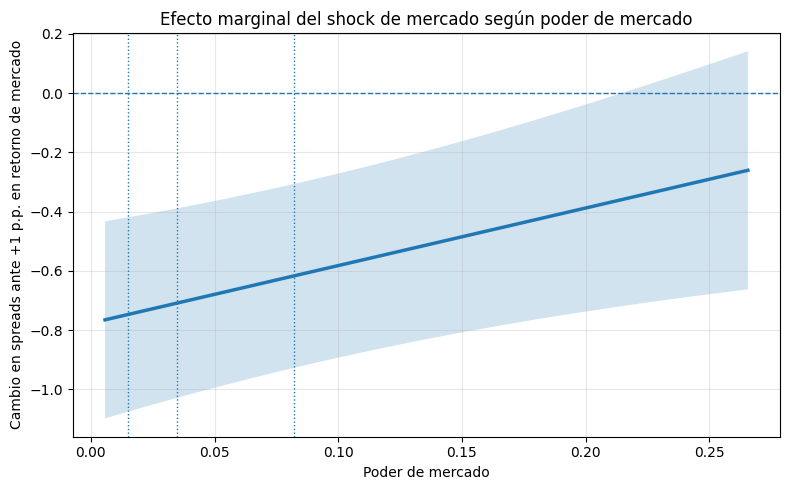

✅ Guardada: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\figures\fig_13_1_market_marginal_effect_1pp.png


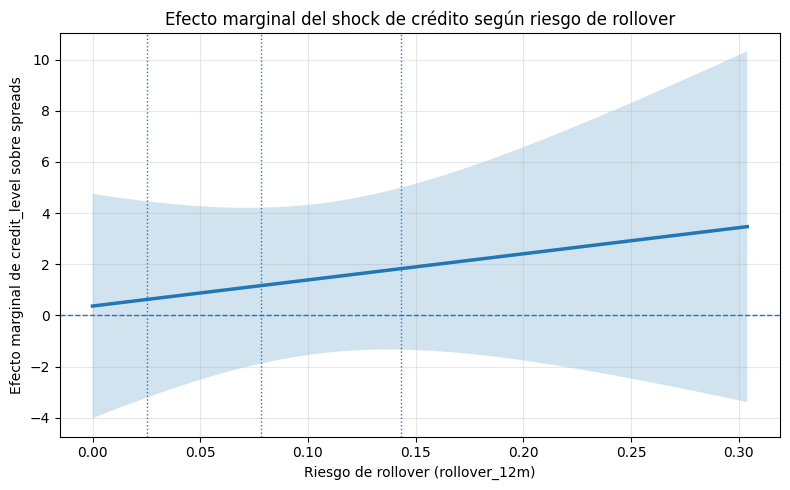

✅ Guardada: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\figures\fig_13_2_credit_marginal_effect_rollover.png
✔ Especificación de crédito usada: main | M6


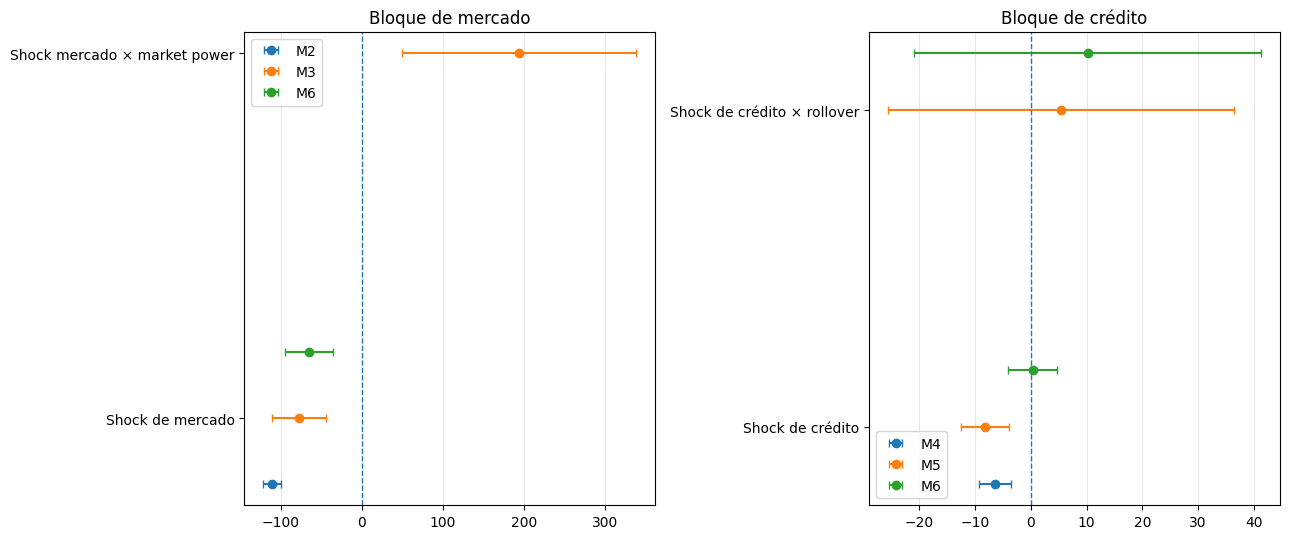

✅ Guardada: C:\Users\vidar\OneDrive\Desktop\UDESA\Tesis\Tesis-main\outputs\figures\fig_13_3_coefplot_modelos_principales_simplified.png

=== FIGURAS BLOQUE 13 GENERADAS ===
- fig_13_1_market_marginal_effect.png
- fig_13_1_market_marginal_effect_1pp.png
- fig_13_2_credit_marginal_effect_rollover.png
- fig_13_3_coefplot_modelos_principales.png
- fig_13_3_coefplot_modelos_principales_simplified.png

=== DATASETS AUXILIARES BLOQUE 13 ===
- fig_13_1_market_marginal_effect_curve.csv
- fig_13_1_market_marginal_effect_curve_raw.csv
- fig_13_1_market_marginal_effect_curve_scaled_1pp.csv
- fig_13_1_market_marginal_effect_percentiles.csv
- fig_13_2_credit_marginal_effect_curve.csv
- fig_13_2_credit_marginal_effect_percentiles.csv
- fig_13_3_coefplot_credit.csv
- fig_13_3_coefplot_credit_simplified.csv
- fig_13_3_coefplot_market.csv
- fig_13_3_coefplot_market_simplified.csv


In [ ]:
# ==========================================================
# 15. FIGURAS ECONOMÉTRICAS PARA TESIS — VERSIÓN REVISADA
# Efectos marginales + coefplot simplificado
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------------------------------------
# 13.1 Paths de output
# ----------------------------------------------------------
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURE_DATA_DIR = RESULTS_DIR / "figure_data"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DATA_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------
# 13.2 Parámetros de presentación
# ----------------------------------------------------------
MARKET_RETURN_PP = 0.01   # 1 punto porcentual = 0.01 en retornos decimales
SAVE_CREDIT_FIG = True    # mantener la figura de crédito como complementaria

# ----------------------------------------------------------
# 13.3 Helpers
# ----------------------------------------------------------
def get_model_sample(df, dep_var, model_config, extra_cols=None):
    """
    Reconstruye la muestra efectiva usada por un modelo dado:
    - toma dep_var + rhs vars del modelo
    - permite agregar columnas extra para graficar moderadores
    - limpia inf y missing
    """
    extra_cols = extra_cols or []
    rhs = list(model_config["vars"])
    needed = list(dict.fromkeys([dep_var] + rhs + extra_cols))

    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas para construir la muestra del modelo: {missing}")

    out = df[needed].copy()
    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.dropna(subset=needed)

    return out


def marginal_effect_curve(res, sample_df, base_var, inter_var, moderator_var,
                          q_low=0.05, q_high=0.95, n_points=80):
    """
    Construye el efecto marginal:
        dY/dX = beta_base + beta_inter * moderator

    y su IC 95% vía delta method.
    """
    for v in [base_var, inter_var]:
        if v not in res.params.index:
            raise ValueError(f"La variable '{v}' no está en los coeficientes del modelo.")

    if moderator_var not in sample_df.columns:
        raise ValueError(f"La variable moderadora '{moderator_var}' no está en la muestra.")

    mod = pd.to_numeric(sample_df[moderator_var], errors="coerce").dropna()
    if mod.empty:
        raise ValueError(f"La variable moderadora '{moderator_var}' no tiene datos válidos.")

    ql = mod.quantile(q_low)
    qh = mod.quantile(q_high)
    grid = np.linspace(ql, qh, n_points)

    b = res.params
    V = res.cov

    b_base = float(b[base_var])
    b_inter = float(b[inter_var])

    var_base = float(V.loc[base_var, base_var])
    var_inter = float(V.loc[inter_var, inter_var])
    cov_bi = float(V.loc[base_var, inter_var])

    effect = b_base + grid * b_inter
    se = np.sqrt(var_base + (grid ** 2) * var_inter + 2 * grid * cov_bi)

    out = pd.DataFrame({
        moderator_var: grid,
        "marginal_effect": effect,
        "se": se,
        "ci_low": effect - 1.96 * se,
        "ci_high": effect + 1.96 * se,
    })

    pct = mod.quantile([0.25, 0.50, 0.75]).rename({
        0.25: "p25",
        0.50: "p50",
        0.75: "p75"
    })
    pct_df = pct.reset_index()
    pct_df.columns = ["percentile", moderator_var]

    return out, pct_df


def rescale_curve(curve_df, scale_factor):
    """
    Reescala efecto marginal e IC por un factor multiplicativo.
    Útil para interpretar mkt_ret en términos de +1 p.p.
    """
    out = curve_df.copy()
    for c in ["marginal_effect", "se", "ci_low", "ci_high"]:
        out[c] = out[c] * scale_factor
    return out


def plot_marginal_effect(curve_df, pct_df, moderator_var, title, xlabel, ylabel, filename):
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(curve_df[moderator_var], curve_df["marginal_effect"], linewidth=2.5)
    ax.fill_between(
        curve_df[moderator_var],
        curve_df["ci_low"],
        curve_df["ci_high"],
        alpha=0.20
    )
    ax.axhline(0, linestyle="--", linewidth=1)

    for _, row in pct_df.iterrows():
        ax.axvline(row[moderator_var], linestyle=":", linewidth=1)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


def build_coefplot_df(results_dict, model_names, terms, label_map=None):
    rows = []
    label_map = label_map or {}

    for model_name in model_names:
        if model_name not in results_dict:
            continue

        res = results_dict[model_name]

        for term in terms:
            if term in res.params.index:
                coef = float(res.params[term])
                se = float(res.std_errors[term])

                rows.append({
                    "model": model_name,
                    "term": term,
                    "label": label_map.get(term, term),
                    "coef": coef,
                    "se": se,
                    "ci_low": coef - 1.96 * se,
                    "ci_high": coef + 1.96 * se,
                })

    return pd.DataFrame(rows)


def coefplot_panel(ax, coef_df, model_order, term_order, title):
    if coef_df.empty:
        ax.set_visible(False)
        return

    offsets = np.linspace(-0.18, 0.18, max(len(model_order), 2))
    y_base = {term: i for i, term in enumerate(term_order)}

    for j, model_name in enumerate(model_order):
        sub = coef_df.loc[coef_df["model"] == model_name].copy()
        if sub.empty:
            continue

        sub = sub.loc[sub["term"].isin(term_order)].copy()
        if sub.empty:
            continue

        sub["y"] = sub["term"].map(y_base) + offsets[j]

        ax.errorbar(
            sub["coef"],
            sub["y"],
            xerr=1.96 * sub["se"],
            fmt="o",
            capsize=3,
            label=model_name
        )

    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_yticks(range(len(term_order)))

    labels = []
    for term in term_order:
        label_series = coef_df.loc[coef_df["term"] == term, "label"]
        labels.append(label_series.iloc[0] if not label_series.empty else term)

    ax.set_yticklabels(labels)
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.3)


def choose_credit_spec():
    """
    Elige automáticamente una especificación de crédito válida para
    efectos marginales según lo que efectivamente esté estimado.
    Prioridad:
    1) M6 main (legacy)
    2) M6 shock
    3) M6 level
    """
    candidates = [
        {
            "family": "main",
            "results_dict": results_main,
            "model_name": "M6",
            "model_config": MODEL_SPECS_MAIN["M6"],
            "base_var": "credit_level",
            "inter_var": "credit_level_x_rollover",
            "m4": "M4",
            "m5": "M5",
            "m6": "M6",
            "label_base": "Shock de crédito",
        },
        {
            "family": "shock",
            "results_dict": results_shock,
            "model_name": "M6_shock",
            "model_config": MODEL_SPECS_SHOCK["M6_shock"],
            "base_var": "credit_tightening_shock",
            "inter_var": "credit_tightening_shock_x_rollover",
            "m4": "M4_shock",
            "m5": "M5_shock",
            "m6": "M6_shock",
            "label_base": "Shock de crédito",
        },
        {
            "family": "level",
            "results_dict": results_level,
            "model_name": "M6_level",
            "model_config": MODEL_SPECS_LEVEL["M6_level"],
            "base_var": "credit_market_level_log",
            "inter_var": "credit_market_level_log_x_rollover",
            "m4": "M4_level",
            "m5": "M5_level",
            "m6": "M6_level",
            "label_base": "Nivel agregado de crédito",
        },
    ]

    for cand in candidates:
        res = cand["results_dict"].get(cand["model_name"])
        if res is None:
            continue

        if cand["base_var"] in res.params.index and cand["inter_var"] in res.params.index:
            return cand

    raise ValueError("No encontré una especificación de crédito apta para construir efectos marginales.")


# ----------------------------------------------------------
# 13.4 Figura 13.1 — Efecto marginal del shock de mercado
# según poder de mercado (M3), reescalado a +1 p.p.
# ----------------------------------------------------------
if "M3" not in results_main:
    raise ValueError("No encontré results_main['M3'].")

res_m3 = results_main["M3"]
cfg_m3 = MODEL_SPECS_MAIN["M3"]

sample_m3 = get_model_sample(
    df=df,
    dep_var=DEP_VAR_MAIN,
    model_config=cfg_m3,
    extra_cols=[MARKET_POWER]
)

curve_m3_raw, pct_m3 = marginal_effect_curve(
    res=res_m3,
    sample_df=sample_m3,
    base_var="mkt_ret",
    inter_var="mkt_ret_x_market_power",
    moderator_var=MARKET_POWER
)

# Reescalar a efecto de +1 punto porcentual en retorno de mercado
curve_m3 = rescale_curve(curve_m3_raw, MARKET_RETURN_PP)

curve_m3_raw.to_csv(FIGURE_DATA_DIR / "fig_13_1_market_marginal_effect_curve_raw.csv", index=False)
curve_m3.to_csv(FIGURE_DATA_DIR / "fig_13_1_market_marginal_effect_curve_scaled_1pp.csv", index=False)
pct_m3.to_csv(FIGURE_DATA_DIR / "fig_13_1_market_marginal_effect_percentiles.csv", index=False)

plot_marginal_effect(
    curve_df=curve_m3,
    pct_df=pct_m3,
    moderator_var=MARKET_POWER,
    title="Efecto marginal del shock de mercado según poder de mercado",
    xlabel="Poder de mercado",
    ylabel="Cambio en spreads ante +1 p.p. en retorno de mercado",
    filename="fig_13_1_market_marginal_effect_1pp.png"
)

print("✅ Guardada:", FIGURES_DIR / "fig_13_1_market_marginal_effect_1pp.png")

# ----------------------------------------------------------
# 13.5 Figura 13.2 — Efecto marginal del shock de crédito
# según rollover risk (complementaria)
# ----------------------------------------------------------
credit_spec = choose_credit_spec()

res_credit = credit_spec["results_dict"][credit_spec["model_name"]]
cfg_credit = credit_spec["model_config"]

sample_credit = get_model_sample(
    df=df,
    dep_var=DEP_VAR_MAIN,
    model_config=cfg_credit,
    extra_cols=["rollover_12m"]
)

curve_credit, pct_credit = marginal_effect_curve(
    res=res_credit,
    sample_df=sample_credit,
    base_var=credit_spec["base_var"],
    inter_var=credit_spec["inter_var"],
    moderator_var="rollover_12m"
)

curve_credit.to_csv(FIGURE_DATA_DIR / "fig_13_2_credit_marginal_effect_curve.csv", index=False)
pct_credit.to_csv(FIGURE_DATA_DIR / "fig_13_2_credit_marginal_effect_percentiles.csv", index=False)

if SAVE_CREDIT_FIG:
    plot_marginal_effect(
        curve_df=curve_credit,
        pct_df=pct_credit,
        moderator_var="rollover_12m",
        title="Efecto marginal del shock de crédito según riesgo de rollover",
        xlabel="Riesgo de rollover (rollover_12m)",
        ylabel=f"Efecto marginal de {credit_spec['base_var']} sobre spreads",
        filename="fig_13_2_credit_marginal_effect_rollover.png"
    )

    print("✅ Guardada:", FIGURES_DIR / "fig_13_2_credit_marginal_effect_rollover.png")
    print(f"✔ Especificación de crédito usada: {credit_spec['family']} | {credit_spec['model_name']}")

# ----------------------------------------------------------
# 13.6 Figura 13.3 — Coefplot simplificado
# ----------------------------------------------------------

# ------------------------------
# Panel mercado: solo shock base + interacción con market power
# ------------------------------
market_terms = [
    "mkt_ret",
    "mkt_ret_x_market_power",
]
market_label_map = {
    "mkt_ret": "Shock de mercado",
    "mkt_ret_x_market_power": "Shock mercado × market power",
}
market_models = ["M2", "M3", "M6"]

coef_market = build_coefplot_df(
    results_dict=results_main,
    model_names=market_models,
    terms=market_terms,
    label_map=market_label_map
)

# ------------------------------
# Panel crédito: solo shock base + interacción con rollover
# ------------------------------
credit_terms = [
    credit_spec["base_var"],
    credit_spec["inter_var"],
]
credit_label_map = {
    credit_spec["base_var"]: credit_spec["label_base"],
    credit_spec["inter_var"]: f"{credit_spec['label_base']} × rollover",
}
credit_models = [
    credit_spec["m4"],
    credit_spec["m5"],
    credit_spec["m6"],
]

coef_credit = build_coefplot_df(
    results_dict=credit_spec["results_dict"],
    model_names=credit_models,
    terms=credit_terms,
    label_map=credit_label_map
)

coef_market.to_csv(FIGURE_DATA_DIR / "fig_13_3_coefplot_market_simplified.csv", index=False)
coef_credit.to_csv(FIGURE_DATA_DIR / "fig_13_3_coefplot_credit_simplified.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=False)

coefplot_panel(
    ax=axes[0],
    coef_df=coef_market,
    model_order=market_models,
    term_order=market_terms,
    title="Bloque de mercado"
)

coefplot_panel(
    ax=axes[1],
    coef_df=coef_credit,
    model_order=credit_models,
    term_order=credit_terms,
    title="Bloque de crédito"
)

axes[0].legend(loc="best")
axes[1].legend(loc="best")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_13_3_coefplot_modelos_principales_simplified.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Guardada:", FIGURES_DIR / "fig_13_3_coefplot_modelos_principales_simplified.png")

# ----------------------------------------------------------
# 13.7 Resumen final
# ----------------------------------------------------------
print("\n=== FIGURAS BLOQUE 13 GENERADAS ===")
for f in sorted(FIGURES_DIR.glob("fig_13_*")):
    print("-", f.name)

print("\n=== DATASETS AUXILIARES BLOQUE 13 ===")
for f in sorted(FIGURE_DATA_DIR.glob("fig_13_*")):
    print("-", f.name)